### **Review of Week 4 Foundation**
*   Before beginning the Week 5 practical work, the Week 4 submission was reviewed. This is a brief transition note summarising that foundation, not a repetition of the full Week 4 documentation.

**1. The Problem Defined**
*   A supervised binary classification problem: predicting, using only information available at the time of booking, whether a scheduled HealthConnect appointment will result in a no-show.
*   The model is intended to help clinic staff prioritise outreach for high-risk appointments, not to automate scheduling decisions.


**2. Week 4 Proposed Approach**
*   Binary target (No-Show vs. Attended), with Cancelled appointments excluded from the primary modelling population.
*   A chronological (time-based) train/test split, to evaluate the model on its ability to predict future appointments from past data.
*   A logistic regression baseline, followed by tree-based ensemble candidates (random forest, gradient boosting).
*   Evaluation using precision, recall, F1-score and ROC-AUC, rather than accuracy alone.


**3. HealthConnect Resources Used**
*   HealthConnect Appointment Dataset (5,000 records) – the primary data source for all analysis.
*   HealthConnect Data Dictionary – used to interpret each variable's definition and expected values.
*   HealthConnect Clinic Knowledge Base – consulted specifically to confirm that a ‘Cancelled’ appointment reflects a proactive patient action, distinct from a silent no-show.


**4. Key Assumptions and Limitations Identified**
*   The dataset is fictional and synthetic; findings are illustrative of methodology rather than clinically validated.
*   The status of waiting_time_minutes was unresolved and flagged as a possible data-leakage risk pending clarification.
*   The decision to exclude Cancelled appointments from the target definition was noted as sensitive to the clinic's actual operational priorities.
*   Model fairness across demographic subgroups (gender, age) was identified as needing review before any real-world use.


**5. What Was Proposed for Week 5**
*   Resolve the waiting_time_minutes question with the data owner; complete a formal statistical and correlation review of the candidate features; finish categorical encoding and numerical scaling; and train and evaluate the proposed baseline model.
*   This proposed scope is carried forward and assessed against what was actually delivered in the accompanying Week 5 Project Summary.


In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

### **Data preparation**

**Data Inspection**

In [ ]:
# Load and dsiplay dataset
df = pd.read_csv("/content/sample_data/HealthConnect_Appointment_Data.csv")
df.head(5)

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


. **Create a Week 5 working copy**



In [ ]:
# create a copy of the original dataset
week5 = df.copy()

### **Shape**

In [ ]:
week5.shape

(5000, 18)

**Interpretation**
*   The dataset consists of **5000 rows** and **18 columns**


In [ ]:
# Display a concise summary of the week5 dataset,
# including the number of rows, columns, non-null values,
# data types, and memory usage.

week5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       3634 non-null   object 
 15  dist

**Columns**

In [ ]:
# Display all column names in the week5 dataset as a list.

week5.columns.tolist()

['appointment_id',
 'patient_id',
 'gender',
 'age',
 'age_group',
 'appointment_type',
 'booking_date',
 'appointment_date',
 'appointment_day',
 'appointment_time',
 'booking_lead_days',
 'previous_appointments',
 'previous_no_shows',
 'reminder_sent',
 'reminder_channel',
 'distance_to_clinic_km',
 'waiting_time_minutes',
 'appointment_outcome']

### **Descriptive statisrics**

In [ ]:
# Generate descriptive statistics for all columns in the dataset,
# including both numerical and categorical variables.

# Transpose the output so that each variable appears as a row,
# making the results easier to read and compare.

week5.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
appointment_id,5000,5000,HC-05000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
patient_id,5000,1696,P-1742,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,5000,3,Female,2488,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5000.0,NaN,NaN,NaN,48.7948,18.138547,18.0,33.0,49.0,64.0,80.0
age_group,5000,6,65+,1241,NaN,NaN,NaN,NaN,NaN,NaN,NaN
appointment_type,5000,4,General Consultation,2086,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_date,5000,593,8/24/2025,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
appointment_date,5000,545,3/14/2026,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
appointment_day,5000,7,Wednesday,737,NaN,NaN,NaN,NaN,NaN,NaN,NaN
appointment_time,5000,3,Morning,2227,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Interpretation**

*   **Total Records:** There are 5000 entries in the dataset.

*   **Unique Identifiers:** `appointment_id` has 5000 unique values, confirming it as a primary key. `patient_id` has 1696 unique values, indicating that multiple appointments are recorded for the same patient.

*   **Categorical Features:**
    *   **gender:**  Three unique values with 'Female' being the most frequent (2488 occurrences).
    *   **age_group:** Six unique age groups, with '65+' being the most common (1241 occurrences).
    *   **appointment_type:** Four unique types, with 'General Consultation' being the most frequent (2086 occurrences).
    *   **booking_date** and **appointment_date:** These are currently `object` type but represent dates. They have 593 and 545 unique values respectively. They will need to be converted to datetime objects for proper time-series analysis.
    *   **appointment_day:** Seven unique days, with 'Wednesday' being the most frequent (737 occurrences).
    *   **appointment_time:** Three unique times (Morning, Afternoon, Evening), with 'Morning' being the most frequent (2227 occurrences).
    *   **reminder_sent:** Two unique values ('Yes', 'No'), with 'Yes' being the most frequent (3634 occurrences).
    *   **reminder_channel:** Three unique values, with 'SMS' being the most frequent (2000 occurrences). This column has **1366 missing values** (5000 - 3634 = 1366), which needs to be addressed.
    *   **appointment_outcome:** Three unique values ('No-Show', 'Attended', 'Cancelled'), with 'No-Show' being the most frequent (2423 occurrences).

*   **Numerical Features:**
    *   **age:** Ranges from 18 to 80, with a mean of approximately 48.8. The standard deviation is about 18.14.
    *   **booking_lead_days:** Ranges from 0 to 60 days, with a mean of approximately 29.64. This indicates how many days in advance an appointment was booked.
    *   **previous_appointments:** Ranges from 0 to 11, with a mean of approximately 3.01. This suggests some patients have several prior appointments.
    *   **previous_no_shows:** Ranges from 0 to 5, with a mean of approximately 0.54. This indicates a relatively low average number of previous no-shows, but the max of 5 suggests some patients are repeat no-showers.
    *   **distance_to_clinic_km:** Ranges from 0.5 to 45.0 km, with a mean of approximately 10.11 km. This column has **90 missing values** (5000 - 4910 = 90).
    *   **waiting_time_minutes:** Ranges from 2 to 68 minutes, with a mean of approximately 24.19 minutes. This column has **60 missing values** (5000 - 4940 = 60).

**Key Observations and Next Steps:**

1.  **Missing Values:** The `reminder_channel`, `distance_to_clinic_km`, and `waiting_time_minutes` columns have missing values that need to be handled. `reminder_channel` has a significant number of missing values (1366), which is notable.
2.  **Date Conversion:** `booking_date` and `appointment_date` are currently objects and should be converted to datetime objects for proper temporal analysis.
3.  **Feature Engineering Potential:** `booking_lead_days`, `previous_appointments`, `previous_no_shows`, `distance_to_clinic_km`, and `waiting_time_minutes` are numerical features that could be directly used or transformed for modeling. Categorical features might require encoding.
4.  **Target Variable:** `appointment_outcome` is the target variable of interest, and its distribution shows 'No-Show' as the most frequent outcome, which could be a concern for the clinic.

### **Data types**
*   The `week5.dtypes` output provides a clear overview of the current data type for each column in the DataFrame. Understanding these types is crucial for data manipulation, analysis, and model building.



In [ ]:
week5.dtypes

,0
appointment_id,object
patient_id,object
gender,object
age,int64
age_group,object
appointment_type,object
booking_date,object
appointment_date,object
appointment_day,object
appointment_time,object


**Interpretation**

*   **Object (Categorical/String Data):**
    *   `appointment_id`, `patient_id`, `gender`, `age_group`, `appointment_type`, `booking_date`, `appointment_date`, `appointment_day`, `appointment_time`, `reminder_sent`, `reminder_channel`, `appointment_outcome` are all of `object` type.
    *   Columns like `gender`, `age_group`, `appointment_type`, `appointment_day`, `appointment_time`, `reminder_sent`, `reminder_channel`, and `appointment_outcome` are categorical features. They are correctly represented as `object` type, but some might benefit from conversion to a `category` dtype for memory efficiency and specific categorical operations.
    *   `booking_date` and `appointment_date` are also `object` types. These are date fields and **must be converted to `datetime` objects** for any time-based analysis (e.g., calculating durations, extracting year/month/day, or plotting time series).
    *   `appointment_id` and `patient_id` are unique identifiers and are appropriately `object` type (strings).

*   **Integer (`int64` - Numerical Data):**
    *   `age`, `booking_lead_days`, `previous_appointments`, and `previous_no_shows` are all `int64` (integer) type.
    *   These columns contain discrete numerical values and are suitable for direct numerical analysis.

*   **Float (`float64` - Numerical Data with Decimals):**
    *   `distance_to_clinic_km` and `waiting_time_minutes` are `float64` (floating-point) type.
    *   These columns represent continuous numerical values, and the `float64` type is appropriate. The presence of `float64` for these columns also indicates that they might contain missing values (NaN, which is a float type in pandas), which was confirmed in the descriptive statistics.


### **Incorrect data types**

It is crucial to identify and convert columns with incorrect data types, especially dates, to ensure accurate calculations and analyses. Misidentified data types can lead to errors in operations like calculating time differences or statistical analysis.

**Convert the booking and appointment dates to proper datetime fields.**

In [ ]:
# Convert the booking_date column from text/object format
# to a proper datetime format.

week5['booking_date'] = pd.to_datetime(week5['booking_date'])

# Convert the appointment_date column to datetime format
# so that date-based calculations and analysis can be performed.

week5['appointment_date'] = pd.to_datetime(week5['appointment_date'])


# Verify the conversion
week5[['booking_date', 'appointment_date']].dtypes

,0
booking_date,datetime64[ns]
appointment_date,datetime64[ns]


In [ ]:
# Validate the conversion
week5[["booking_date", "appointment_date", "booking_lead_days"]].head()

,booking_date,appointment_date,booking_lead_days
0,2025-02-06,2025-02-18,12
1,2026-02-25,2026-02-27,2
2,2025-11-16,2025-12-24,38
3,2025-07-18,2025-08-28,41
4,2025-07-09,2025-08-25,47


**Calculate the time difference between the appointment date and the booking date**

In [ ]:
# Calculate the number of days between the booking date
# and the scheduled appointment date.

week5["appointment_date"] - week5["booking_date"]

,0
0,12 days
1,2 days
2,38 days
3,41 days
4,47 days
...,...
4995,28 days
4996,60 days
4997,21 days
4998,34 days


This tells you how far in advance the appointment was booked.

The dataset already has a variable booking_lead_days So this calculation is essentially checking whether booking_lead_days correctly represents the difference between booking_date and appointment_date.

In [ ]:
# Calculate the lead time from the appointment and booking dates.

calculated_lead_days = (
    week5["appointment_date"] - week5["booking_date"]
).dt.days

# Compare the calculated values with the existing booking_lead_days column.

week5[["booking_lead_days"]].assign(
    calculated_lead_days=calculated_lead_days
).head()

,booking_lead_days,calculated_lead_days
0,12,12
1,2,2
2,38,38
3,41,41
4,47,47


### **Booking Lead-Day Consistency Check**

The supplied `booking_lead_days` field is validated against the difference between `appointment_date` and `booking_date`. This is an internal consistency check and forms part of the wider inconsistent-record assessment below.

**Validate booking lead days**

In [ ]:
# Calculate the number of days between booking and appointment dates.
# This is used to validate the existing booking_lead_days variable.
week5["calculated_lead_days"] = (
    week5["appointment_date"] -
    week5["booking_date"]
).dt.days

# Compare the supplied and calculated booking lead times.
week5[
    [
        "booking_date",
        "appointment_date",
        "booking_lead_days",
        "calculated_lead_days"
    ]
].head()

,booking_date,appointment_date,booking_lead_days,calculated_lead_days
0,2025-02-06,2025-02-18,12,12
1,2026-02-25,2026-02-27,2,2
2,2025-11-16,2025-12-24,38,38
3,2025-07-18,2025-08-28,41,41
4,2025-07-09,2025-08-25,47,47


In [ ]:
# Count records where the supplied booking lead time
# differs from the value calculated from the two dates.
(
    week5["booking_lead_days"] !=
    week5["calculated_lead_days"]
).sum()

np.int64(0)

They match, so i will later remove calculated_lead_days because it was only created for validation.

### **Missing values Handling**

Handling missing values appropriately is a critical step in data preparation. The strategy for imputation or removal depends on the nature and extent of missingness, as well as the potential impact on data leakage. Careful consideration ensures that the imputed data does not introduce bias or use information that would not be available at the time of prediction.

In [ ]:
# Check for missing values in the specified columns
missing_values = week5[['reminder_channel', 'distance_to_clinic_km', 'waiting_time_minutes']].isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
dtype: int64


In [ ]:
# Count missing values in each column.
missing_count = week5.isnull().sum()

# Calculate the percentage of missing values in each column.
missing_percentage = (
    week5.isnull().mean() * 100
)

# Combine the counts and percentages into a summary table.
missing_summary = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_percentage
})

# Display only columns that contain missing values.
missing_summary[
    missing_summary["Missing_Count"] > 0
].sort_values(
    "Missing_Percentage",
    ascending=False
)

,Missing_Count,Missing_Percentage
reminder_channel,1366,27.32
distance_to_clinic_km,90,1.80
waiting_time_minutes,60,1.20


**Interpretation**
*   reminder_channel has the highest missingness at **27.32%**, likely because a reminder channel is not applicable when no reminder was sent.
*   distance_to_clinic_km has only **1.80%** missing values.
*   waiting_time_minutes has the lowest missingness at **1.20%**.
*   The missingness is relatively low except for reminder_channel, which should be handled separately based on the meaning of the missing values.

**Investigate reminder-channel missingness**

In [ ]:
# Examine the relationship between reminder_sent and reminder_channel.
# This helps determine whether missing reminder channels are genuine
# missing values or structurally missing because no reminder was sent.
pd.crosstab(
    week5["reminder_sent"],
    week5["reminder_channel"],
    dropna=False
)

reminder_channel,Email,SMS,WhatsApp,NaN
reminder_sent,,,,
No,0,0,0,1366
Yes,533,2000,1101,0


**Interpretation**
*   reminder_sent = No and reminder_channel = NaN: There are **1366 appointments** where no reminder was sent, and consequently, the reminder channel is NaN (missing). This confirms that the missing reminder_channel values are structurally missing when no reminder was sent.
*   reminder_sent = Yes and reminder_channel = Email: **533 appointments** had a reminder sent via Email.
*   reminder_sent = Yes and reminder_channel = SMS: **2000 appointments** had a reminder sent via SMS.
*   reminder_sent = Yes and reminder_channel = WhatsApp: **1101 appointments** had a reminder sent via WhatsApp.
*   reminder_sent = Yes and reminder_channel = NaN: The 0 here confirms that when a reminder was sent, its channel was always recorded (no missing channels when a reminder was actually sent).

In [ ]:
# Replace missing reminder_channel values with "No Reminder".
# This preserves the business meaning because no channel exists
# when a reminder was not sent.
week5["reminder_channel"] = (
    week5["reminder_channel"]
    .fillna("No Reminder")
)

# Confirm the updated reminder-channel categories.
week5["reminder_channel"].value_counts(
    dropna=False
)

,count
reminder_channel,
SMS,2000
No Reminder,1366
WhatsApp,1101
Email,533


**Interpretation**
*   **SMS** was the most common reminder channel, accounting for **40.00% of appointments**.
*   **No Reminder**accounted for **27.32%**, while **WhatsApp** and **Email** represented **22.02%** and **10.66%**, respectively.
*   This indicates that SMS was the preferred reminder method, while a substantial proportion of appointments did not receive a reminder.

**Investigate missing distance values**

In [ ]:
# Display records where distance_to_clinic_km is missing.
# This helps assess whether the missingness follows any obvious pattern.
week5[
    week5["distance_to_clinic_km"].isna()
].head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,calculated_lead_days
38,HC-00039,P-0072,Male,78,65+,General Consultation,2025-04-02,2025-06-01,Sunday,Afternoon,60,6,1,Yes,SMS,NaN,42.0,Cancelled,60
176,HC-00177,P-1036,Male,65,65+,General Consultation,2026-01-15,2026-01-27,Tuesday,Morning,12,2,0,Yes,Email,NaN,28.0,No-Show,12
443,HC-00444,P-1114,Female,53,45-54,Follow-up,2025-08-06,2025-09-24,Wednesday,Afternoon,49,4,1,No,No Reminder,NaN,18.0,No-Show,49
503,HC-00504,P-0705,Female,21,18-24,General Consultation,2026-03-06,2026-04-19,Sunday,Afternoon,44,3,0,Yes,SMS,NaN,36.0,No-Show,44
581,HC-00582,P-1596,Male,38,35-44,Follow-up,2026-02-10,2026-04-01,Wednesday,Morning,50,1,0,Yes,SMS,NaN,11.0,No-Show,50


In [ ]:
# Review the distribution and summary statistics for distance.
week5["distance_to_clinic_km"].describe()

,distance_to_clinic_km
count,4910.000000
mean,10.109572
std,6.590030
min,0.500000
25%,5.300000
50%,8.700000
75%,13.500000
max,45.000000


**Interpretation**
*   The `distance_to_clinic_km` variable contains **4,910** recorded values, **with 90 observations (1.8%) missing**. The **mean distance** is approximately **10.11 km**, while the **median is 8.7 km**.
*   Half of the recorded appointments involve patients
living between 5.3 km and 13.5 km from the clinic.
*   The mean being higher than the median, together with a **maximum distance of 45 km**, suggests a positively skewed distribution in which a smaller number of patients live considerably farther from the clinic.

In [ ]:
# Calculate the median distance using available observations.
# Median imputation may be appropriate if the missing values are limited
# and no systematic missingness is identified.
distance_median = (
    week5["distance_to_clinic_km"].median()
)

distance_median

8.7

**Interpretation**
*   The **median distance to the clinic was 8.7 km**, meaning that half of the appointments were associated with patients living **within 8.7 km** of the clinic, while the other half were **more than 8.7 km away**.

**Consideration**
*   The **distance_to_clinic_km** is information known before the appointment takes place (at the time of booking).
*   Therefore, using an imputed value for this feature will not lead to data leakage in a model predicting appointment outcomes at booking time.



In [ ]:
# Replace missing distance values with the median distance.
week5["distance_to_clinic_km"] = (
    week5["distance_to_clinic_km"]
    .fillna(distance_median)
)

In [ ]:
# verify if there any missing values in the distance_to_clinic_km column
week5["distance_to_clinic_km"].isna().sum()

np.int64(0)

No missing values

**Investigate waiting-time missingness**

In [ ]:
# Display records where waiting_time_minutes is missing.
week5[
    week5["waiting_time_minutes"].isna()
].head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,calculated_lead_days
54,HC-00055,P-1767,Female,45,45-54,Follow-up,2025-09-26,2025-09-29,Monday,Evening,3,2,0,No,No Reminder,11.3,NaN,Attended,3
161,HC-00162,P-0306,Female,28,25-34,Diagnostic Test,2025-12-28,2025-12-29,Monday,Morning,1,3,1,Yes,SMS,17.8,NaN,No-Show,1
191,HC-00192,P-0482,Female,53,45-54,Follow-up,2025-10-17,2025-12-11,Thursday,Afternoon,55,4,2,Yes,WhatsApp,9.7,NaN,No-Show,55
260,HC-00261,P-1569,Male,29,25-34,General Consultation,2026-01-09,2026-03-10,Tuesday,Afternoon,60,5,1,Yes,SMS,9.8,NaN,No-Show,60
343,HC-00344,P-0344,Male,57,55-64,Follow-up,2025-09-12,2025-10-09,Thursday,Morning,27,2,0,Yes,WhatsApp,4.6,NaN,Attended,27


In [ ]:
# Review the distribution of waiting-time values.
week5["waiting_time_minutes"].describe()

,waiting_time_minutes
count,4940.000000
mean,24.189676
std,10.863184
min,2.000000
25%,17.000000
50%,24.000000
75%,32.000000
max,68.000000


**Consideration**
*   The waiting_time_minutes feature represents the time a patient actually waited for their appointment. This information becomes available during or after the appointment itself.
*   Since the goal is to predict appointment outcomes (**like 'No-Show' or 'Attended'**) at the time of booking (i.e., before the appointment takes place), then waiting_time_minutes would not be available before prediction.
*   Therefore, imputing waiting_time_minutes and using it directly as a feature for a model trying to predict outcomes at booking time would lead to data leakage, as I'd be using future information to predict a past event.
For such a model, you would generally exclude this feature or consider engineering a feature from it that is available at booking time (e.g., historical average waiting times for that clinic/doctor, if available, but not the specific waiting time for the current appointment).

**Leakage note:** The waiting-time finding above is consolidated in the dedicated **Potential Data Leakage** assessment later in the data-preparation section.

### **Duplicates**

Ensuring that duplicate records are handled correctly is essential for maintaining data integrity and preventing biased analysis. While `appointment_id` should be unique per row, `patient_id` is expected to have multiple entries, indicating repeat patients, which is a valid part of the dataset structure.

**Check duplicate records**

In [ ]:
# Count completely duplicated rows in the dataset.
week5.duplicated().sum()

np.int64(0)

Confirm that appointment_id behaves as a unique appointment identifier. This is a crucial step in data validation for several reasons:

*   **Data Integrity:** It ensures that every record in your dataset represents a distinct appointment and that there are no accidental duplicate entries at the primary key level.
*   **Reliable Analysis:** If appointment_id were not unique, any analysis or aggregations based on individual appointments (e.g., calculating average waiting times per appointment) would be flawed.
*   **No Duplicate Appointments:** A unique appointment_id confirms that each row corresponds to one specific appointment instance, preventing overcounting or misinterpretation of appointment-level data.




In [ ]:
# Confirm that appointment_id behaves as a unique appointment identifier.
week5["appointment_id"].nunique()

5000

**Interpretation**
*   This value of **5000** matches the total number of rows in the dataset.
*   This means that for each of the **5000 rows (appointments)**, there is a distinct and unique appointment_id.
*   This confirms that appointment_id can reliably serve as a primary key for your dataset, identifying each appointment unequivocally.

In [ ]:
# Count the number of unique patients.
# Multiple appointments from the same patient are expected
# and should not be treated as duplicate records.
week5["patient_id"].nunique()

1696

**Interpretation**
*   There are **1696 unique patients** in your dataset.
*   Even though the dataset contains 5000 appointments, these appointments are spread across **1696 distinct patients**, indicating that many patients have multiple appointments recorded.



## **Data Quality and Leakage Assessment**

### **Inconsistent Records**

The following checks assess logical consistency, plausible numerical ranges, and agreement with known clinic business rules. These are data-quality checks rather than leakage checks.

**a) Check historical appointment consistency**
*   This ensures that the **previous_appointments** and **previous_no_shows**counts make logical sense. For instance, previous_no_shows should not exceed **previous_appointments**.
*   This helps validate the integrity of patient history data, which is often a strong predictor of future behaviour.







In [ ]:
# Identify logically inconsistent records where previous no-shows
# exceed the total number of previous appointments.
week5[
    week5["previous_no_shows"] >
    week5["previous_appointments"]
]

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,calculated_lead_days


**b) Check booking-date consistency**
*   This check verifies that booking_date and appointment_date are correctly formatted and that their relationship (e.g., booking_lead_days) is consistent.
*   Validating booking_lead_days against the calculated difference is vital for time-series analysis and for ensuring that your 'lead time' feature accurately reflects the booking behavior.




In [ ]:
# Identify any records where the booking date occurs
# after the scheduled appointment date.
week5[
    week5["booking_date"] >
    week5["appointment_date"]
]

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,calculated_lead_days


In [ ]:
# Identify negative booking lead times.
# Negative values would indicate an inconsistent record.
week5[
    week5["booking_lead_days"] < 0
]

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,calculated_lead_days


**c) Inspect plausible numerical ranges**
*   This involves looking at the minimum, maximum, mean, and distribution of numerical features like **age**, **booking_lead_days**, **distance_to_clinic_km**, and **waiting_time_minutes**.
*   It helps identify outliers, data entry errors (e.g., an age of 200), or unexpected distributions that might require further investigation or transformation before modeling.



In [ ]:
# Review patient-age values for potentially implausible observations.
week5["age"].describe()

,age
count,5000.000000
mean,48.794800
std,18.138547
min,18.000000
25%,33.000000
50%,49.000000
75%,64.000000
max,80.000000


**Interpretation**
*   The dataset contains **5,000 patients**, with no missing age values.
*   The **mean age is 48.79 years**, while the **median is 49 years**, indicating that the centre of the distribution is around 49 years.
*   Ages range from **18 to 80 years**, showing a wide range of patient ages.
*   **25%** of patients are aged **33 or younger**.
*   **50%** of patients are aged **49 or younger**.
*   **75%** of patients are aged **64 or younger**.
*   The **standard deviation of 18.14 years** indicates considerable variation in patient ages.

In [ ]:
# Review distance values for potentially unusual or invalid records.
week5["distance_to_clinic_km"].describe()

,distance_to_clinic_km
count,5000.000000
mean,10.084200
std,6.533127
min,0.500000
25%,5.300000
50%,8.700000
75%,13.325000
max,45.000000


**Interpretation**
*   The dataset contains **5,000 recorded distances**, with no missing values.
*   The **average distance to the clinic is 10.08 km**, while the **median is 8.7 km**.
*   Distances range from **0.5 km to 45 km**, showing considerable variation.
*   **25%** of patients live **5.3 km or less** from the clinic.
*   **75%** of patients live **13.33 km or less** from the clinic.
*   The **standard deviation of 6.53 km** indicates moderate variation in distance.

In [ ]:
# Review waiting-time values for potential unusual observations.
week5["waiting_time_minutes"].describe()

,waiting_time_minutes
count,4940.000000
mean,24.189676
std,10.863184
min,2.000000
25%,17.000000
50%,24.000000
75%,32.000000
max,68.000000


**Interpretation**
*   There are **4,940 recorded waiting times**, indicating **60 missing values**.
*   The **average waiting time is 24.19** minutes, with a **median of 24 minutes**.
*   Waiting times range from **2 to 68 minutes**.
*   **25%** of patients wait **17 minutes or less**, while **75%** wait **32 minutes or less**.
*   The **standard deviation of 10.86 minutes** indicates moderate variation in waiting times.

At this stage I would not automatically fill waiting_time_minutes until I settle the leakage question

**d) Investigate Sunday appointments**

In [ ]:
# Review the number of appointments scheduled on each day of the week.
week5["appointment_day"].value_counts()

,count
appointment_day,
Wednesday,737
Sunday,737
Friday,728
Saturday,724
Monday,701
Tuesday,689
Thursday,684


**Interpretation**
*   **Wednesday and Sunday** have the highest number of appointments, with **737 each**.
*   Thursday has the fewest appointments, with **684**.
*   The counts across the seven days are relatively similar, ranging from **684 to 737**.
*   This suggests that appointments are fairly evenly distributed throughout the week, with only small differences between days.


In [ ]:
# Count appointments recorded on Sundays.
# This is important because the HealthConnect Knowledge Base
# indicates that the clinic is closed on Sundays.
sunday_appointments = week5[
    week5["appointment_day"] == "Sunday"
]

sunday_appointments.shape

(737, 19)

**Interpretation**
*   There are **737 appointments** scheduled on a Sunday, and these records have **19 columns**.
*   This is a significant finding because the 'HealthConnect Knowledge Base' states that the clinic is closed on Sundays. This discrepancy suggests a potential data anomaly that needs further investigation. It could mean:

*   **Data entry errors:** Sundays were mistakenly entered as appointment days.
*   **Special circumstances:** The clinic might operate on Sundays under specific, unrecorded conditions (e.g., emergency appointments, specific services).
*   **Data quality issue:** The 'Knowledge Base' information might be outdated or incomplete, or the dataset itself has inconsistencies.

In [ ]:
# Display a sample of Sunday appointment records
# for further investigation.
sunday_appointments.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,calculated_lead_days
6,HC-00007,P-0776,Male,58,55-64,Diagnostic Test,2025-01-17,2025-02-16,Sunday,Afternoon,30,4,1,Yes,WhatsApp,8.2,30.0,No-Show,30
29,HC-00030,P-0983,Female,30,25-34,General Consultation,2025-08-17,2025-08-31,Sunday,Morning,14,2,1,No,No Reminder,5.0,12.0,No-Show,14
38,HC-00039,P-0072,Male,78,65+,General Consultation,2025-04-02,2025-06-01,Sunday,Afternoon,60,6,1,Yes,SMS,8.7,42.0,Cancelled,60
42,HC-00043,P-0612,Female,41,35-44,Follow-up,2025-12-25,2026-01-18,Sunday,Morning,24,2,1,No,No Reminder,3.6,24.0,Attended,24
43,HC-00044,P-0834,Female,70,65+,Diagnostic Test,2025-06-09,2025-07-13,Sunday,Afternoon,34,2,0,Yes,SMS,2.6,11.0,No-Show,34


Sunday appointments were identified despite the clinic Knowledge Base indicating Sunday closure. Because the dataset is fictional and the source material does not explain this discrepancy, the records were retained for analysis while the inconsistency was documented as a data-quality consideration

### **Handling Sunday Appointments**

Sunday appointments are retained because the source material does not confirm that they are erroneous. A binary `is_sunday_appointment` flag is created so the discrepancy can be tracked explicitly during analysis. Because the clinic Knowledge Base states that the clinic is closed on Sundays, this feature and its interpretation should be treated cautiously and documented as a data-quality limitation rather than assumed to represent normal clinic operations.

### **Potential Data Leakage**

The intended prediction point is **before the scheduled appointment takes place**. Therefore, predictors should contain only information that would be available before the appointment outcome is known.

- **`appointment_outcome` — direct target leakage:** used to create `no_show`; it must not be included in `X`.
- **`waiting_time_minutes` — temporal leakage:** becomes known during/after the appointment, so it is excluded from predictive features but may be examined descriptively.
- **Historical variables — timing check:** `previous_appointments` and `previous_no_shows` are retained only under the assumption that they describe history before the current appointment.
- **Identifiers:** `appointment_id` is excluded. `patient_id` is used for grouping, not as an ordinary predictor.
- **Repeated-patient leakage:** a row-level random split could place the same patient in training and test data. A grouped split by `patient_id` is therefore used later.
- **Preprocessing leakage:** encoding/scaling is performed after splitting; the scaler is fitted on training data only.

In [ ]:
# Document fields that must not be used as ordinary predictors.
fields_not_for_predictors = [
    "appointment_outcome",      # directly reveals the target
    "waiting_time_minutes",     # unavailable at booking-time prediction
    "appointment_id",           # record identifier
    "patient_id"                # grouping variable, not a model feature
]

print("Fields excluded from ordinary predictors:")
for field in fields_not_for_predictors:
    print(f"- {field}")

Fields excluded from ordinary predictors:
- appointment_outcome
- waiting_time_minutes
- appointment_id
- patient_id


### **Data Exploration & Visual Evidence**

**Create the modelling population**

In [ ]:
# Define a list of columns that should be present in model_df
# This ensures consistency and explicitly includes 'is_sunday_appointment'
model_df_columns_to_keep = [
    'appointment_id', 'patient_id', 'gender', 'age', 'age_group',
    'appointment_type', 'booking_date', 'appointment_date', 'appointment_day',
    'appointment_time', 'booking_lead_days', 'previous_appointments',
    'previous_no_shows', 'reminder_sent', 'reminder_channel',
    'distance_to_clinic_km', 'waiting_time_minutes', 'appointment_outcome',
    'is_sunday_appointment'
]

# Create a new binary feature 'is_sunday_appointment' directly here to ensure it's always available.
# This feature will be 1 if the appointment_day is 'Sunday', and 0 otherwise.
week5['is_sunday_appointment'] = (week5['appointment_day'] == 'Sunday').astype(int)

# Create a separate dataset for the primary binary modelling problem.
# Cancelled appointments are excluded because they are neither
# attended appointments nor no-shows.
# Filter week5 and select only the desired columns to create model_df
model_df = week5[
    week5["appointment_outcome"].isin(["Attended", "No-Show"])
][model_df_columns_to_keep].copy()

# Ensure booking_date and appointment_date are datetime objects in model_df
model_df['booking_date'] = pd.to_datetime(model_df['booking_date'])
model_df['appointment_date'] = pd.to_datetime(model_df['appointment_date'])

# Confirm the remaining appointment outcomes.
print("Appointment outcomes in model_df:")
print(model_df["appointment_outcome"].value_counts())
print("\nColumns in model_df after creation:")
print(model_df.columns.tolist())

Appointment outcomes in model_df:
appointment_outcome
No-Show     2423
Attended    2314
Name: count, dtype: int64

Columns in model_df after creation:
['appointment_id', 'patient_id', 'gender', 'age', 'age_group', 'appointment_type', 'booking_date', 'appointment_date', 'appointment_day', 'appointment_time', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'reminder_sent', 'reminder_channel', 'distance_to_clinic_km', 'waiting_time_minutes', 'appointment_outcome', 'is_sunday_appointment']


**Create the binary target**

In [ ]:
# Create the binary target variable:
# 0 = Attended
# 1 = No-Show
model_df["no_show"] = (
    model_df["appointment_outcome"]
    .map({
        "Attended": 0,
        "No-Show": 1
    })
)

# Confirm the target counts.
model_df["no_show"].value_counts()

,count
no_show,
1,2423
0,2314


In [ ]:
# Calculate the percentage distribution of the target variable.
model_df["no_show"].value_counts(
    normalize=True
) * 100

,proportion
no_show,
1,51.150517
0,48.849483


**Plot the target distribution**

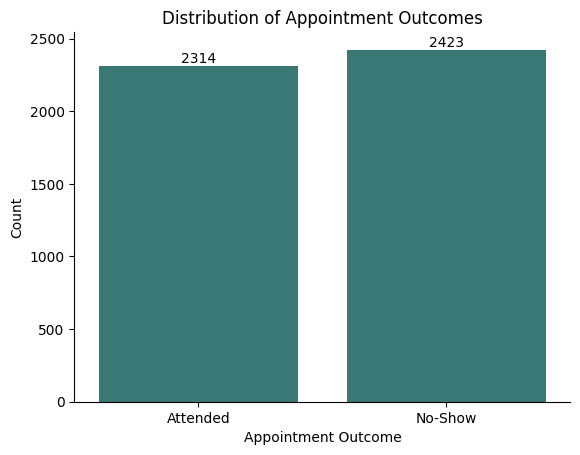

In [ ]:
# Create a count plot to examine whether
# the modelling target is balanced.
ax = sns.countplot(
    data=model_df,
    color="#2F837F",
    x="no_show"
)

# Add chart title and axis labels.
plt.title(
    "Distribution of Appointment Outcomes"
)

plt.xlabel("Appointment Outcome")

plt.ylabel( "Count")

# Replace numeric target labels with meaningful names.
plt.xticks(
    [0, 1],
    ["Attended", "No-Show"]
)

# Add the count above each bar.
for container in ax.containers:
    ax.bar_label(container)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(False)

# Display the chart.
plt.show()

#### **Interpretation**
* **What the visualization shows:** This count plot displays the distribution of `no_show`, where 0 = Attended and 1 = No-Show.
* **What was observed:** The two classes are close in size, indicating an approximately balanced modelling population.
* **How the observation informed decisions:** Severe class imbalance is not present. The later patient-aware split prioritises preventing repeated-patient leakage, and class proportions are checked after splitting.

### **Univariate Analysis**

### **Data Exploration: Distribution Plots, Boxplots, and Count Plots**

### **a) Histograms and Distribution Plots for Numerical Variables**

These plots help us understand the shape, spread, and central tendency of numerical features.

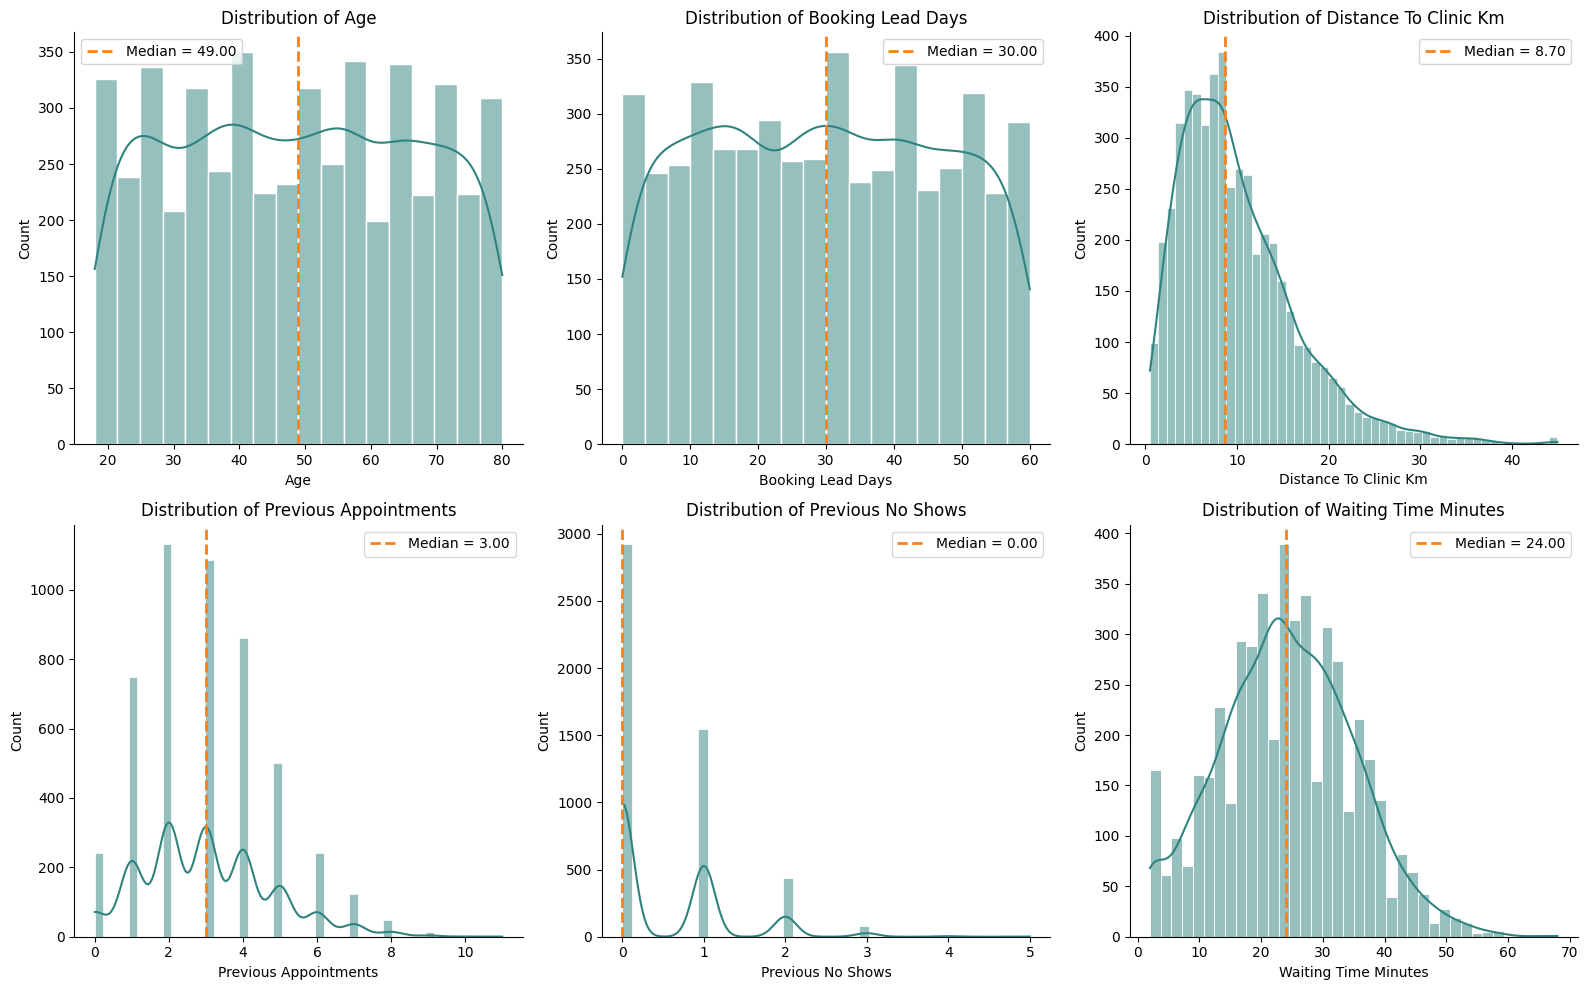

In [ ]:
# List the numerical features to analyse.
numerical_features = [
    "age",
    "booking_lead_days",
    "distance_to_clinic_km",
    "previous_appointments",
    "previous_no_shows",
    "waiting_time_minutes"
]

# Create a 2-row by 3-column subplot layout.
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Flatten the axes array so it is easier to loop through.
axes = axes.flatten()

# Get a representative colour from the viridis colormap.
viridis_color = plt.cm.viridis(0.5)

# Create one histogram for each numerical feature.
for i, col in enumerate(numerical_features):

    # Create the histogram with KDE.
    sns.histplot(
        data=week5,
        x=col,
        kde=True,
        ax=axes[i],
        color="#2F837F",
        edgecolor="white"
    )

    # Calculate the median.
    median_value = week5[col].median()

    # Add a vertical line at the median.
    axes[i].axvline(
        median_value,
        color="#F5821F",
        linestyle="--",
        linewidth=2,
        label=f"Median = {median_value:.2f}"
    )

    # Add a descriptive title.
    axes[i].set_title(
        f"Distribution of {col.replace('_', ' ').title()}"
    )

    # Add x-axis label.
    axes[i].set_xlabel(
        col.replace("_", " ").title()
    )

    # Add y-axis label.
    axes[i].set_ylabel("Count")

    # Show the median in the legend.
    axes[i].legend()

    # Apply styling to each subplot.
    axes[i].spines[["top", "right"]].set_visible(False)
    axes[i].grid(False)

# Adjust spacing so titles and labels do not overlap.
plt.tight_layout()

# Display the complete figure.
plt.show()

#### **Distribution of Patient Age**
*   **What it shows:** This histogram with a Kernel Density Estimate (KDE) displays the frequency distribution of patient ages, with a median line indicating the central tendency.
*   **What was observed:** The age distribution appears to be bimodal, with peaks around 30-40 and 60-70 years old. The median age is **49.0 years**. There are no obvious extreme outliers, and the data covers a broad range from late teens to 80s.
*   **How it informs decisions:** The bimodal distribution suggests that `age` or `age_group` might be an important feature for distinguishing patient segments. It might be beneficial for modeling to either keep `age` as a continuous variable or consider `age_group` if the model struggles with the continuous bimodal nature. No specific preprocessing for outliers is immediately indicated for `age`.

#### **Distribution of Booking Lead Days**
*   **What it shows:** This plot illustrates how many days in advance appointments are typically booked, with a median line indicating the central tendency.
*   **What was observed:** The distribution is relatively uniform, with a slight peak for appointments booked very close to the actual appointment date (low lead days). The median booking lead days is **30.0 days**. Most appointments are booked within a 60-day window.
*   **How it informs decisions:** The wide and somewhat uniform distribution indicates that `booking_lead_days` is a meaningful feature, capturing a variety of booking behaviors. It can be directly used in models. No specific transformation is immediately suggested unless a model struggles with its uniform nature.

#### **Distribution of Distance to Clinic (km)**
*   **What it shows:** This plot visualizes the distribution of distances patients travel to the clinic, with a median line indicating the central tendency.
*   **What was observed:** The distribution is right-skewed, meaning most patients live relatively close to the clinic, with a long tail extending to higher distances. The median distance to clinic is **8.7 km**. There are a few patients traveling quite far.
*   **How it informs decisions:** The right-skewness and presence of higher values might make this feature sensitive to models that assume normal distributions. Log transformation or power transformation could be considered during preprocessing if necessary. The imputed median values have integrated well into the distribution without creating obvious anomalies.

#### **Distribution of Previous Appointments**
*   **What it shows:** This plot indicates the frequency of patients based on their total number of previous appointments, with a median line indicating the central tendency.
*   **What was observed:** The distribution is right-skewed, with many patients having a low number of previous appointments and progressively fewer patients having a high number. The median number of previous appointments is **3.0**. There are patients with up to 11 previous appointments.
*   **How it informs decisions:** This feature likely reflects patient loyalty or chronicity of health conditions. Its skewed nature might necessitate transformations (e.g., square root, log) if linear models are used, or it can be directly used as-is for tree-based models. It's a strong candidate for a predictive feature.

#### **Distribution of Previous No-Shows**
*   **What it shows:** This plot shows the distribution of patients based on how many times they have previously missed an appointment, with a median line indicating the central tendency.
*   **What was observed:** The distribution is heavily skewed to the right, with a large majority of patients having 0 previous no-shows. The median number of previous no-shows is **0.0**. A small but significant number of patients have 1 or more previous no-shows, going up to 5.
*   **How it informs decisions:** This feature is a critical indicator of past behavior and is highly likely to be a strong predictor for future no-shows. Due to its highly skewed nature, it might be beneficial to create a binary feature (e.g., `has_previous_no_shows`) or apply a transformation, especially for models sensitive to feature scale or distribution. This suggests that previous no-shows are a very strong predictor of future no-shows.

#### **Distribution of Waiting Time (Minutes)**
*   **What it shows:** This plot displays the distribution of recorded patient waiting times for appointments, with a median line indicating the central tendency.
*   **What was observed:** The distribution appears somewhat normal, centered around 20-30 minutes, with values ranging from 2 to 68 minutes. The median waiting time is **24.0 minutes**. There are no clear extreme values in the recorded data.
*   **How it informs decisions:** As previously noted, `waiting_time_minutes` is a post-appointment feature, making it unsuitable for direct use in a model predicting appointment outcomes *at booking time* due to data leakage. The observation of its distribution is valuable for understanding the clinic's operations but confirms its exclusion or careful handling during feature selection for a booking-time prediction model. If predicting *cancellation* (which can happen after waiting), it might be engineered as a post-booking feature.

### **b) Boxplots for Potential Outliers**

Boxplots are useful for identifying potential outliers and understanding the spread and skewness of numerical features.

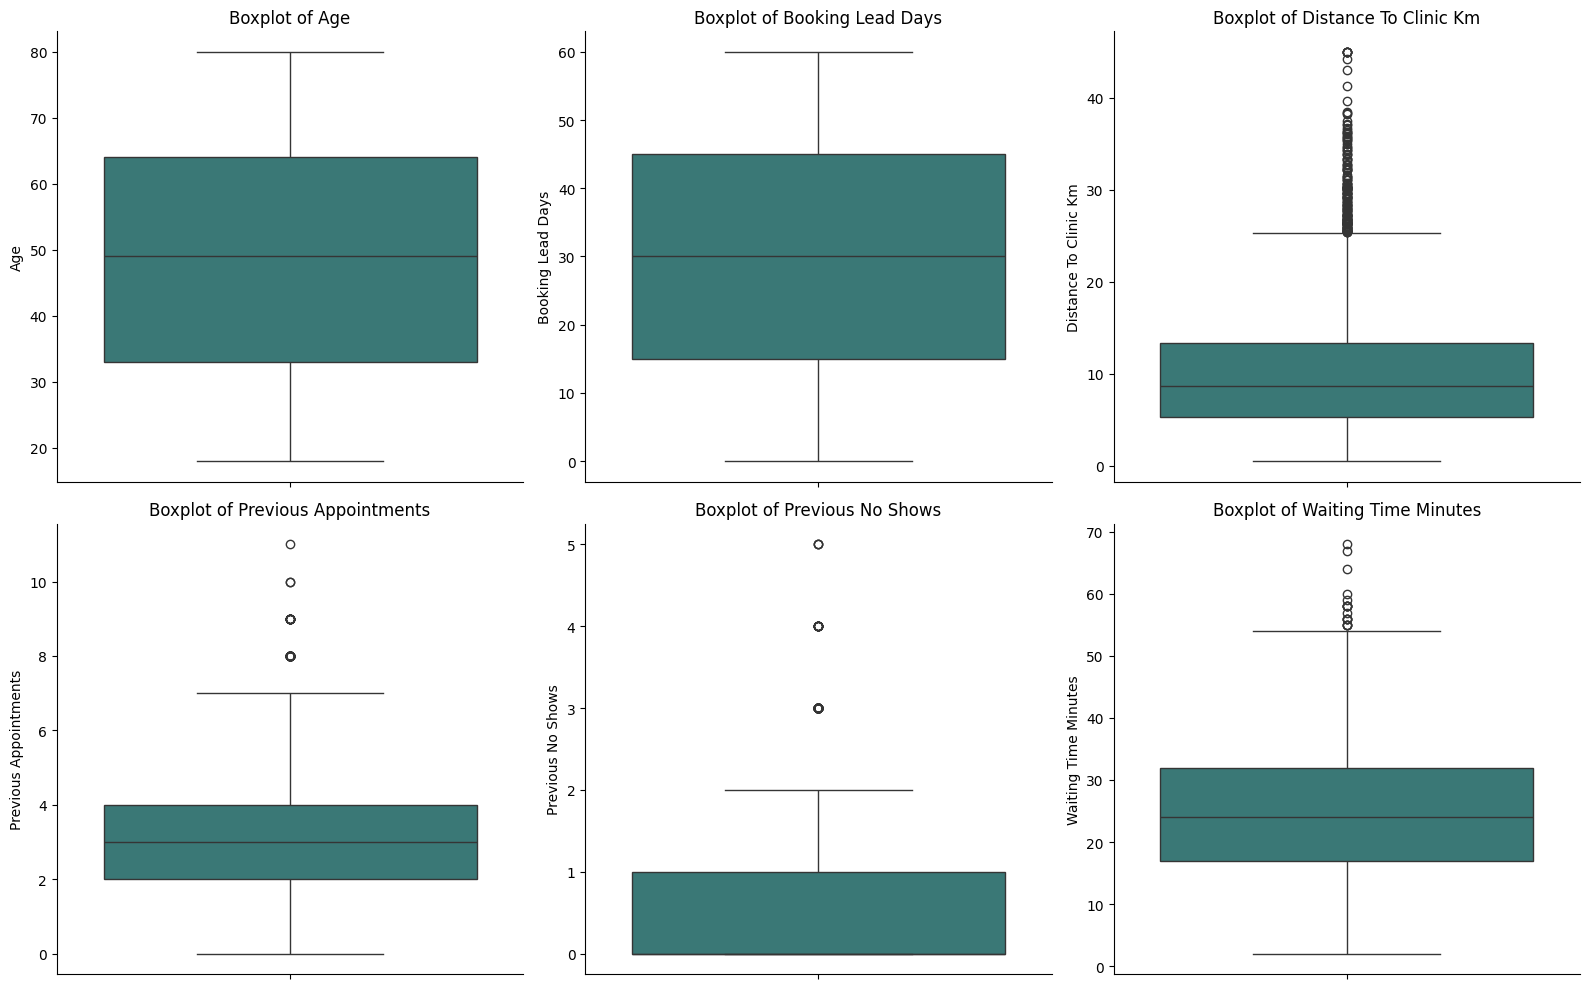

In [ ]:
# List the numerical features to analyse.
numerical_features = [
    "age",
    "booking_lead_days",
    "distance_to_clinic_km",
    "previous_appointments",
    "previous_no_shows",
    "waiting_time_minutes"
]

# Create a 2-row by 3-column subplot layout.
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Flatten the axes array so it is easier to loop through.
axes = axes.flatten()

# Create one boxplot for each numerical feature.
for i, col in enumerate(numerical_features):

    # Create the boxplot.
    sns.boxplot(
        data=week5,
        y=col,
        ax=axes[i],
        color="#2F837F"
    )

    # Add a descriptive title.
    axes[i].set_title(
        f"Boxplot of {col.replace('_', ' ').title()}"
    )

    # Add y-axis label.
    axes[i].set_ylabel(
        col.replace("_", " ").title()
    )

    # Remove the x-axis label because the feature
    # is already identified by the title.
    axes[i].set_xlabel("")

    # Remove the top and right borders.
    axes[i].spines[["top", "right"]].set_visible(False)

    # Remove gridlines.
    axes[i].grid(False)

# Adjust spacing so titles and labels do not overlap.
plt.tight_layout()

# Display the complete figure.
plt.show()

#### **Boxplot of Patient Age**
*   **What it shows:** This boxplot visualizes the spread and potential outliers in the `age` variable.
*   **What was observed:** The boxplot shows the median age around 49. The interquartile range (IQR) is visible, and the whiskers extend to typical data ranges. No explicit outliers are indicated beyond the whiskers, confirming the earlier observation from the histogram that age values are within a plausible range.
*   **How it informs decisions:** The absence of extreme outliers in `age` suggests that no special outlier treatment (e.g., capping, removal) is required for this feature, which simplifies preprocessing.

####  **Boxplot of Booking Lead Days**
*   **What it shows:** This boxplot visualizes the distribution and potential outliers for the `booking_lead_days` feature.
*   **What was observed:** The median is around 30 days. The boxplot shows a fairly symmetrical distribution, and there are no significant outliers detected. The range of values is consistent with the histogram.
*   **How it informs decisions:** The lack of outliers indicates that `booking_lead_days` is a clean feature in terms of extreme values. It can be used directly without outlier-specific preprocessing.

#### **Boxplot of Distance to Clinic (km)**
*   **What it shows:** This boxplot displays the distribution and potential outliers in the `distance_to_clinic_km` feature.
*   **What was observed:** The boxplot clearly shows several data points flagged as outliers above the upper whisker, indicating patients who travel significantly longer distances to the clinic compared to the majority. The median is around 8.7 km, consistent with the right-skewness observed in the histogram.
*   **How it informs decisions:** The presence of outliers in `distance_to_clinic_km` suggests that models sensitive to outliers (e.g., linear regression, SVMs) might benefit from robust scaling (like `RobustScaler`) or outlier treatment such as capping (winsorization) these high values. Tree-based models are generally less sensitive to outliers.

#### **Boxplot of Previous Appointments**
*   **What it shows:** This boxplot visualizes the distribution and potential outliers for the `previous_appointments` count.
*   **What was observed:** The plot shows a median of around 3 previous appointments. Several data points are flagged as outliers above the upper whisker, indicating a smaller group of patients with a notably higher number of past appointments (up to 11).
*   **How it informs decisions:** These outliers represent highly frequent visitors, which could be a significant predictive factor. Similar to `distance_to_clinic_km`, depending on the model, robust scaling or capping might be considered. Alternatively, these outliers might represent a distinct patient segment worth investigating further, potentially leading to feature engineering (e.g., a binary flag for 'high previous appointments').

#### **Boxplot of Previous No-Shows**
*   **What it shows:** This boxplot illustrates the distribution and potential outliers in the `previous_no_shows` count.
*   **What was observed:** The median is 0, highlighting that most patients have no previous no-shows. However, there's a clear presence of outliers, representing patients with 1, 2, 3, 4, or 5 previous no-shows. These are very important data points.
*   **How it informs decisions:** The significant presence of outliers (patients with any previous no-shows) reinforces that this feature is crucial. These are not 'errors' but rather meaningful data points. For modeling, these values should likely be retained. Depending on the model, converting `previous_no_shows` into an ordinal categorical feature or a binary feature (`has_previous_no_shows`) could be beneficial, especially given the strong predictive power usually associated with past no-show behavior.

#### **Boxplot of Waiting Time (Minutes)**
*   **What it shows:** This boxplot visualizes the distribution and potential outliers for `waiting_time_minutes` among the non-missing records.
*   **What was observed:** The plot shows the median around 24 minutes. There are some data points flagged as outliers on both the lower and upper ends of the distribution. These represent patients with unusually short or long waiting times, relative to the IQR.
*   **How it informs decisions:** Although this feature will be excluded from the booking-time prediction model due to data leakage, if it were to be used in a different modeling context (e.g., predicting patient satisfaction post-appointment), these outliers might need attention. They could represent special cases or unusual clinic flow events that might warrant investigation or robust treatment. For the current no-show prediction task, this reinforces its non-suitability as a direct feature.

### **c) Count Plots / Bar Charts for Categorical Variables**

These plots are used to visualize the frequency of different categories within qualitative features.

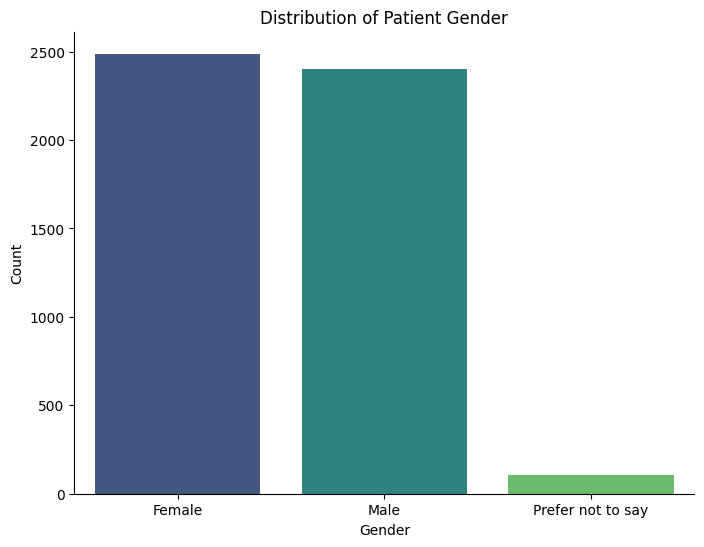

In [ ]:
# Count plot for 'gender'

# Create a count plot for patient gender.
plt.figure(figsize=(8, 6))

ax = sns.countplot(data=week5, x="gender", hue="gender", palette="viridis", legend=False)

# Add a descriptive title.
plt.title("Distribution of Patient Gender")

# Add axis labels.
plt.xlabel("Gender")
plt.ylabel("Count")

# Remove the top and right borders.
ax.spines[["top", "right"]].set_visible(False)

# Remove the default gridlines.
ax.grid(False)



# Display the plot.
plt.show()

**Interpretation**
*   **What it shows:** This count plot displays the number of patients in each gender category.
*   **What was observed:** The categories 'Female' and 'Male' are almost equally represented, with 'Other' having a very small count. This indicates a fairly balanced representation of the primary gender categories.
*   **How it informs decisions:** Given the small count for 'Other', this category might need to be grouped with one of the larger categories or handled separately (e.g., dropped if too sparse for modeling) if it doesn't provide significant predictive power. For 'Female' and 'Male', one-hot encoding or label encoding will be suitable during preprocessing.

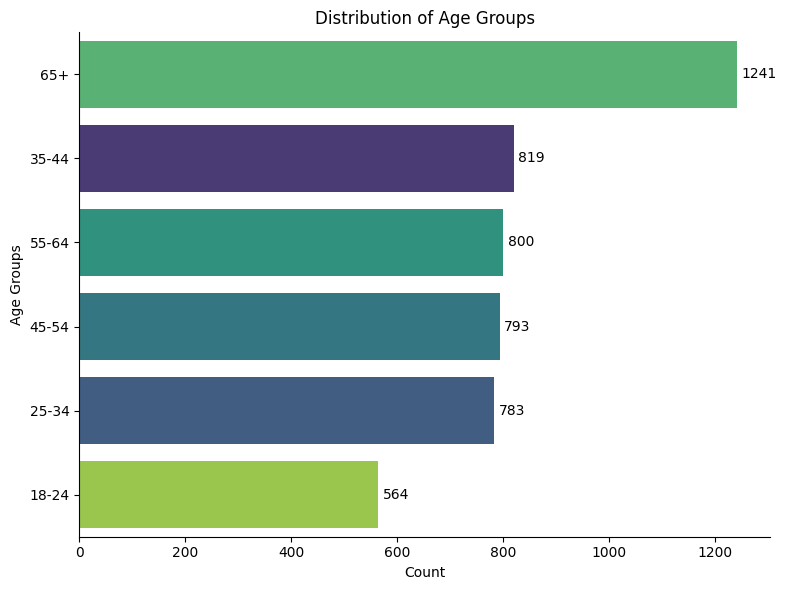

In [ ]:
# Create a count plot for patient age_group.
plt.figure(figsize=(8, 6))

ax = sns.countplot(data=week5,  y='age_group', hue='age_group', palette='viridis', order=week5['age_group'].value_counts().index, legend=False)

# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Add a descriptive title.
plt.title("Distribution of Age Groups")

# Add axis labels.
plt.ylabel("Age Groups")
plt.xlabel("Count")

# Remove the top and right borders.
ax.spines[["top", "right"]].set_visible(False)

# Remove the default gridlines.
ax.grid(False)


# Adjust the spacing to prevent labels and titles from overlapping.
plt.tight_layout()

# Display the plot.
plt.show()


**Interpretation**
*   **What it shows:** This count plot illustrates the frequency of patients across different age groups.
*   **What was observed:** The '65+' age group has the highest count, indicating a significant proportion of older patients. Other age groups show varying, but generally well-represented, counts. There are no sparsely populated age groups.
*   **How it informs decisions:** `age_group` is a well-distributed categorical feature that can be directly used in models after appropriate encoding (e.g., one-hot encoding). Its strong representation across different segments suggests it will be a useful feature for predicting appointment outcomes, potentially capturing distinct behaviors between age demographics.

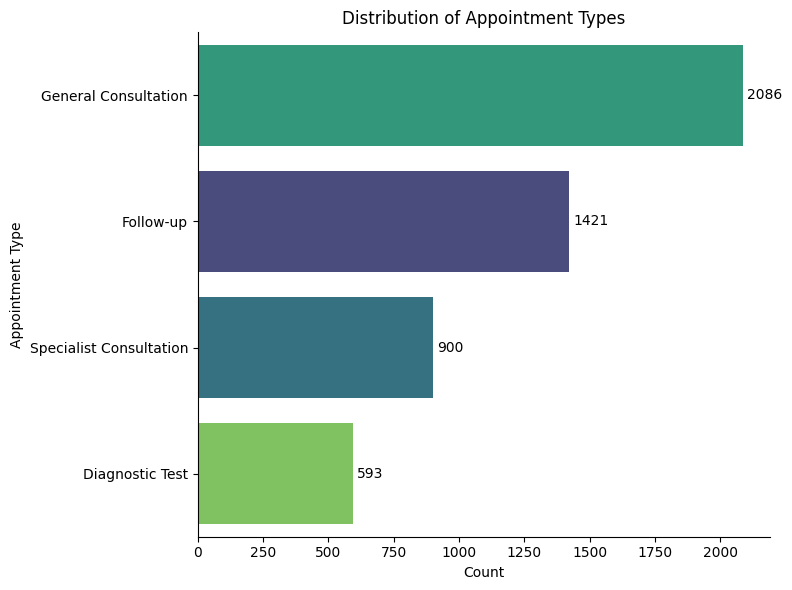

In [ ]:
# Count plot for 'appointment_type'
plt.figure(figsize=(8, 6))

ax = sns.countplot(data=week5, y='appointment_type', hue='appointment_type', palette='viridis', order=week5['appointment_type'].value_counts().index, legend=False)

# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Add a descriptive title.
plt.title("Distribution of Appointment Types")

# Add axis labels.
plt.ylabel("Appointment Type")
plt.xlabel("Count")

# Remove the top and right borders.
ax.spines[["top", "right"]].set_visible(False)

# Remove the default gridlines.
ax.grid(False)


# Adjust the spacing to prevent labels and titles from overlapping.
plt.tight_layout()

# Display the plot.
plt.show()


**Interpretation**
*   **What it shows:** This count plot visualizes the frequency of different types of appointments scheduled.
*   **What was observed:** 'General Consultation' is the most frequent appointment type, followed by 'Follow-up' and 'Specialist Consultation'. 'Diagnostic Test' is the least frequent but still has a substantial number of occurrences. All categories are well-represented.
*   **How it informs decisions:** `appointment_type` is a significant categorical feature that can be one-hot encoded for modeling. The varying frequencies might mean that some appointment types are more prone to no-shows than others, making this a potentially strong predictor.

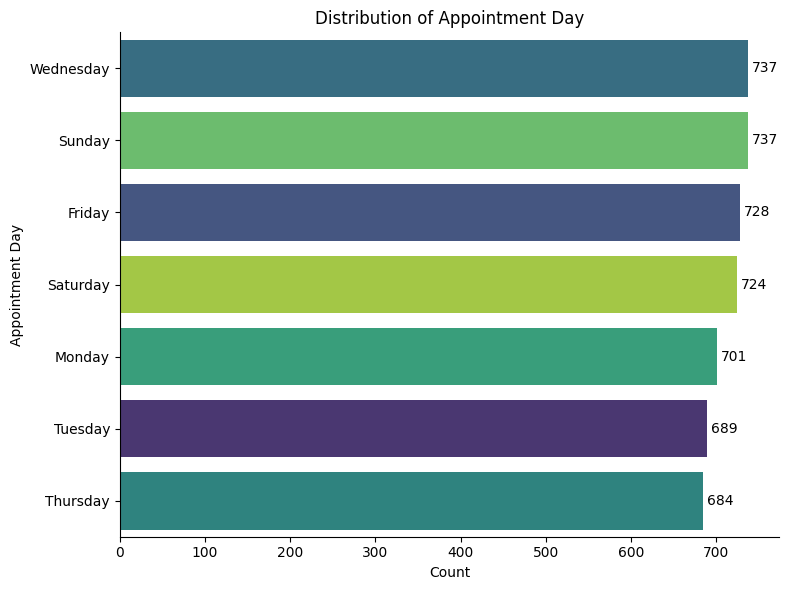

In [ ]:
# Count plot for 'appointment_day'
plt.figure(figsize=(8, 6))

ax = sns.countplot(data=week5, y='appointment_day', hue='appointment_day',
              palette='viridis', order=week5['appointment_day'].value_counts().index, legend=False)


# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Add a descriptive title.
plt.title("Distribution of Appointment Day")

# Add axis labels.
plt.ylabel("Appointment Day")
plt.xlabel("Count")

# Remove the top and right borders.
ax.spines[["top", "right"]].set_visible(False)

# Remove the default gridlines.
ax.grid(False)


# Adjust the spacing to prevent labels and titles from overlapping.
plt.tight_layout()

# Display the plot.
plt.show()


**Interpretation**
*   **What it shows:** This count plot displays the number of appointments scheduled on each day of the week.
*   **What was observed:** Appointments are fairly evenly distributed throughout the week, with Wednesday and Sunday having slightly higher counts. This confirms previous `value_counts` observations. The presence of Sunday appointments despite clinic closure (as per knowledge base) is noted, but the `is_sunday_appointment` feature already accounts for this.
*   **How it informs decisions:** This feature can be one-hot encoded. The created `is_sunday_appointment` binary feature further highlights a potential behavioral difference for Sunday appointments, which could be a valuable feature for modeling, allowing the model to explicitly learn effects related to that specific day.

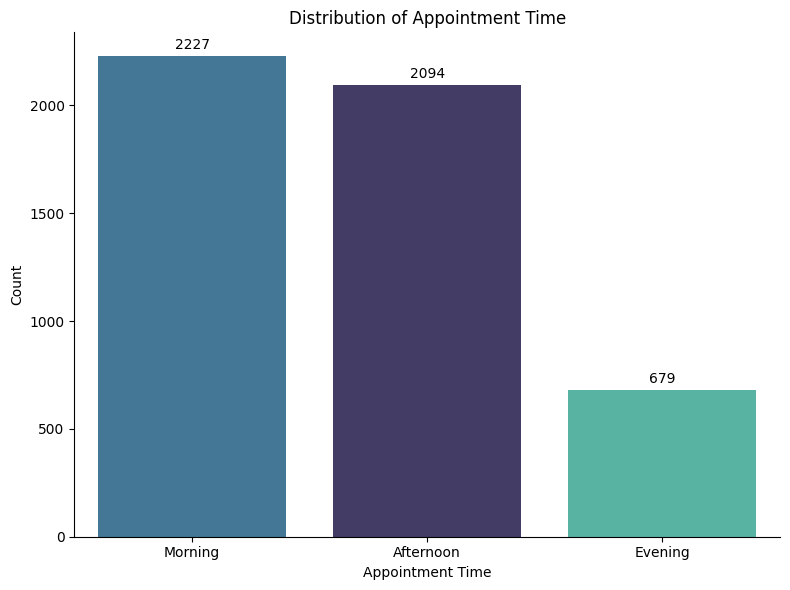

In [ ]:
# Count plot for 'appointment_time'
plt.figure(figsize=(8, 6))

ax = sns.countplot(data=week5, x='appointment_time', hue='appointment_time',
                   palette='mako', order=week5['appointment_time'].value_counts().index, legend=False)


# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Add a descriptive title.
plt.title("Distribution of Appointment Time")

# Add axis labels.
plt.xlabel("Appointment Time")
plt.ylabel("Count")

# Remove the top and right borders.
ax.spines[["top", "right"]].set_visible(False)

# Remove the default gridlines.
ax.grid(False)


# Adjust the spacing to prevent labels and titles from overlapping.
plt.tight_layout()

# Display the plot.
plt.show()

**Interpretation**
*   **What it shows:** This count plot visualizes the frequency of appointments scheduled in the Morning, Afternoon, or Evening.
*   **What was observed:** 'Morning' appointments are the most frequent, followed by 'Afternoon' and 'Evening'. All time slots are well-represented.
*   **How it informs decisions:** `appointment_time` is a categorical feature that can be one-hot encoded. The different frequencies might suggest varying no-show rates depending on the time of day, making it a potentially important feature for the model.

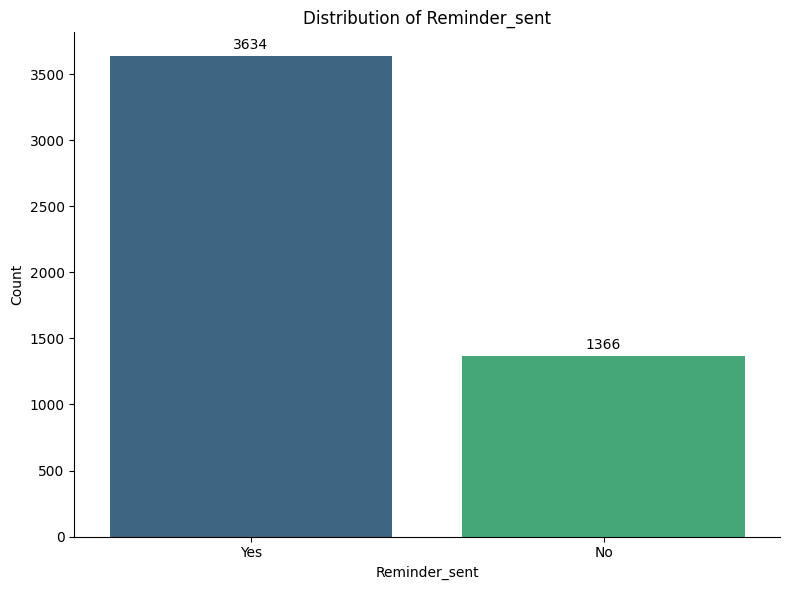

In [ ]:
# Count plot for 'reminder_sent'
plt.figure(figsize=(8, 6))

ax = sns.countplot(data=week5, x='reminder_sent', hue='reminder_sent', palette='viridis', legend=False)


# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Add a descriptive title.
plt.title("Distribution of Reminder_sent")

# Add axis labels.
plt.xlabel("Reminder_sent")
plt.ylabel("Count")

# Remove the top and right borders.
ax.spines[["top", "right"]].set_visible(False)

# Remove the default gridlines.
ax.grid(False)


# Adjust the spacing to prevent labels and titles from overlapping.
plt.tight_layout()

# Display the plot.
plt.show()



**Interpretation**
*   **What it shows:** This count plot illustrates whether a reminder was sent for an appointment.
*   **What was observed:** The majority of appointments (`Yes`) had a reminder sent, while a significant portion (`No`) did not. The classes are somewhat imbalanced but both are substantial.
*   **How it informs decisions:** This is a crucial binary feature that indicates an intervention designed to reduce no-shows. It should be one-hot encoded. The relationship between `reminder_sent` and `appointment_outcome` will be very important for the model to learn.

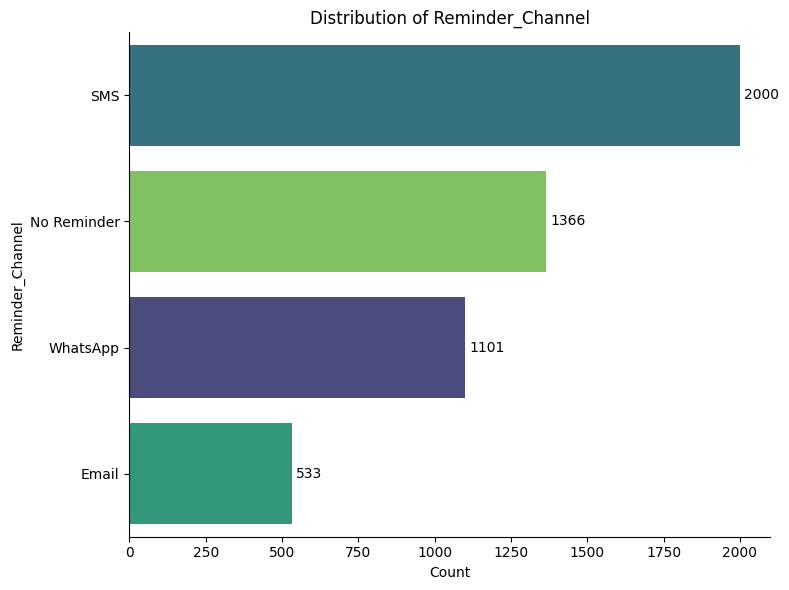

In [ ]:
# Count plot for 'reminder_channel' (after imputation)
plt.figure(figsize=(8, 6))

ax = sns.countplot(data=week5, y='reminder_channel', hue='reminder_channel',
              palette='viridis', order=week5['reminder_channel'].value_counts().index, legend=False)


# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Add a descriptive title.
plt.title("Distribution of Reminder_Channel")

# Add axis labels.
plt.ylabel("Reminder_Channel")
plt.xlabel("Count")

# Remove the top and right borders.
ax.spines[["top", "right"]].set_visible(False)

# Remove the default gridlines.
ax.grid(False)


# Adjust the spacing to prevent labels and titles from overlapping.
plt.tight_layout()

# Display the plot.
plt.show()



**Interpretation**
*   **What it shows:** This count plot displays the distribution of different reminder channels, including the imputed 'No Reminder' category.
*   **What was observed:** 'SMS' is the most popular channel, followed by 'No Reminder' (which includes cases where no reminder was sent). 'WhatsApp' and 'Email' are less frequent. All categories are well-represented.
*   **How it informs decisions:** This categorical feature, now without missing values, is ready for one-hot encoding. The `No Reminder` category effectively captures the absence of a reminder, which is structurally important. The model can use these channels to identify if certain communication methods are more effective than others in preventing no-shows.

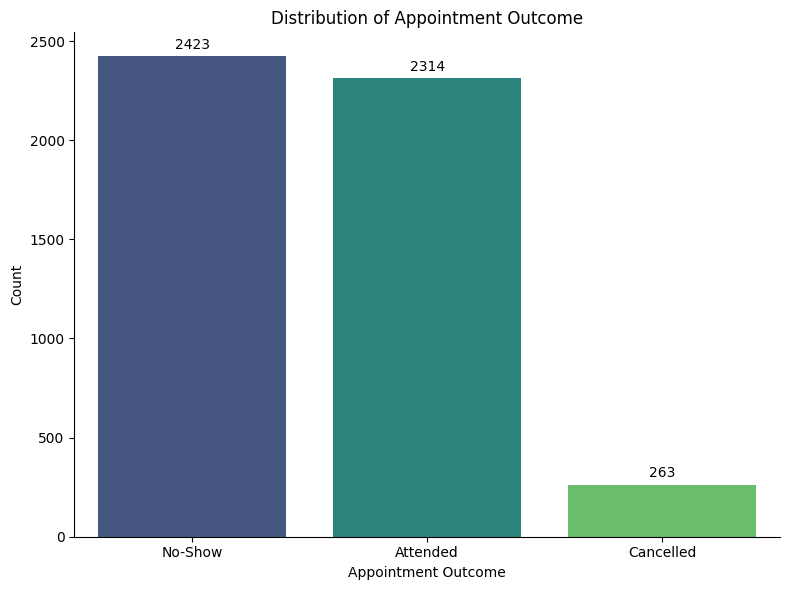

In [ ]:
# Count plot for 'appointment_outcome'
plt.figure(figsize=(8, 6))

ax = sns.countplot(
    data=week5,
    x="appointment_outcome",
    hue="appointment_outcome",
    palette="viridis",
    order=week5["appointment_outcome"].value_counts().index,
    legend=False
)


# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Add a descriptive title.
plt.title("Distribution of Appointment Outcome")

# Add axis labels.
plt.xlabel("Appointment Outcome")
plt.ylabel("Count")

# Remove the top and right borders.
ax.spines[["top", "right"]].set_visible(False)

# Remove the default gridlines.
ax.grid(False)


# Adjust the spacing to prevent labels and titles from overlapping.
plt.tight_layout()

# Display the plot.
plt.show()


**Interpretation**
*   **What it shows:** This count plot displays the distribution of the original `appointment_outcome` variable, including 'Cancelled' appointments.
*   **What was observed:** 'No-Show' is the most frequent outcome, followed by 'Attended', and then 'Cancelled'. The counts show that 'No-Show' and 'Attended' are somewhat balanced, while 'Cancelled' is a smaller but still significant category.
*   **How it informs decisions:** This visualization confirms the need to filter out 'Cancelled' appointments when focusing on the binary 'Attended' vs. 'No-Show' prediction task, as already done when creating `model_df`. For multi-class classification (predicting all three outcomes), the class imbalance with 'Cancelled' would need to be addressed during modeling or evaluation.

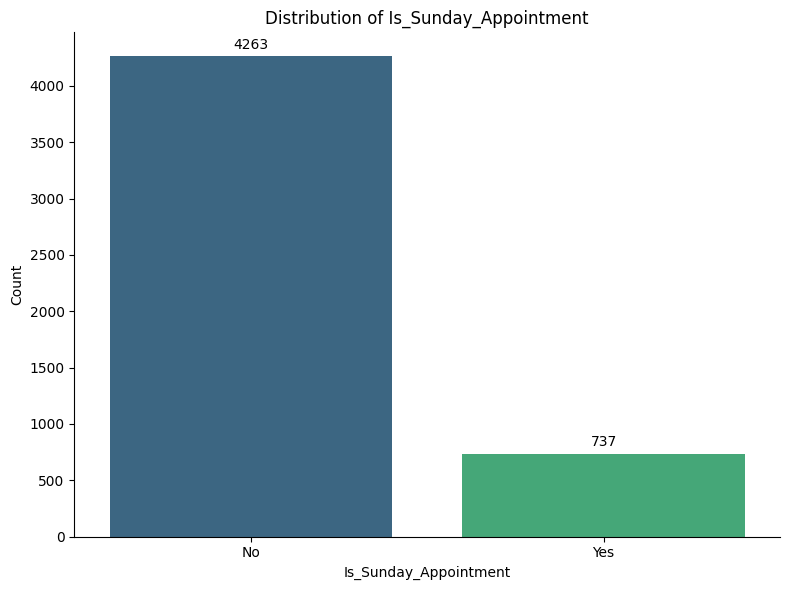

In [ ]:

# Convert the binary variable from 0/1 to No/Yes.
week5["is_sunday_appointment"] = week5["is_sunday_appointment"].map({
    0: "No",
    1: "Yes"
})

# Count plot for 'is_sunday_appointment'
plt.figure(figsize=(8, 6))

ax = sns.countplot(data=week5, x='is_sunday_appointment', hue='is_sunday_appointment',
              palette='viridis', legend=False)

# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container, padding=3)

# Add a descriptive title.
plt.title("Distribution of Is_Sunday_Appointment")

# Add axis labels.
plt.xlabel("Is_Sunday_Appointment")
plt.ylabel("Count")

# Remove the top and right borders.
ax.spines[["top", "right"]].set_visible(False)

# Remove the default gridlines.
ax.grid(False)


# Adjust the spacing to prevent labels and titles from overlapping.
plt.tight_layout()

# Display the plot.
plt.show()


**Interpretation**
*   **What it shows:** This count plot displays the frequency of appointments that fall on a Sunday versus those that do not.
*   **What was observed:** A significant number of appointments (737) are flagged as Sunday appointments, which is roughly 15% of the total dataset. The majority are non-Sunday appointments.
*   **How it informs decisions:** This new binary feature is ready for direct use in modeling after potential scaling. It allows the model to capture any unique patterns or no-show behaviors associated with Sunday appointments, which was identified as a data quality consideration. This feature engineering step addresses the `appointment_day` anomaly explicitly.

### **Bivariate Analysis**

**Previous no-shows vs current outcome**

In [ ]:
# Numerical features to compare against appointment outcome.
numerical_bivariate = [
    "age",
    "booking_lead_days",
    "distance_to_clinic_km",
    "previous_appointments",
    "previous_no_shows",
    "waiting_time_minutes"
]

**Numerical features vs Appointment Outcome**

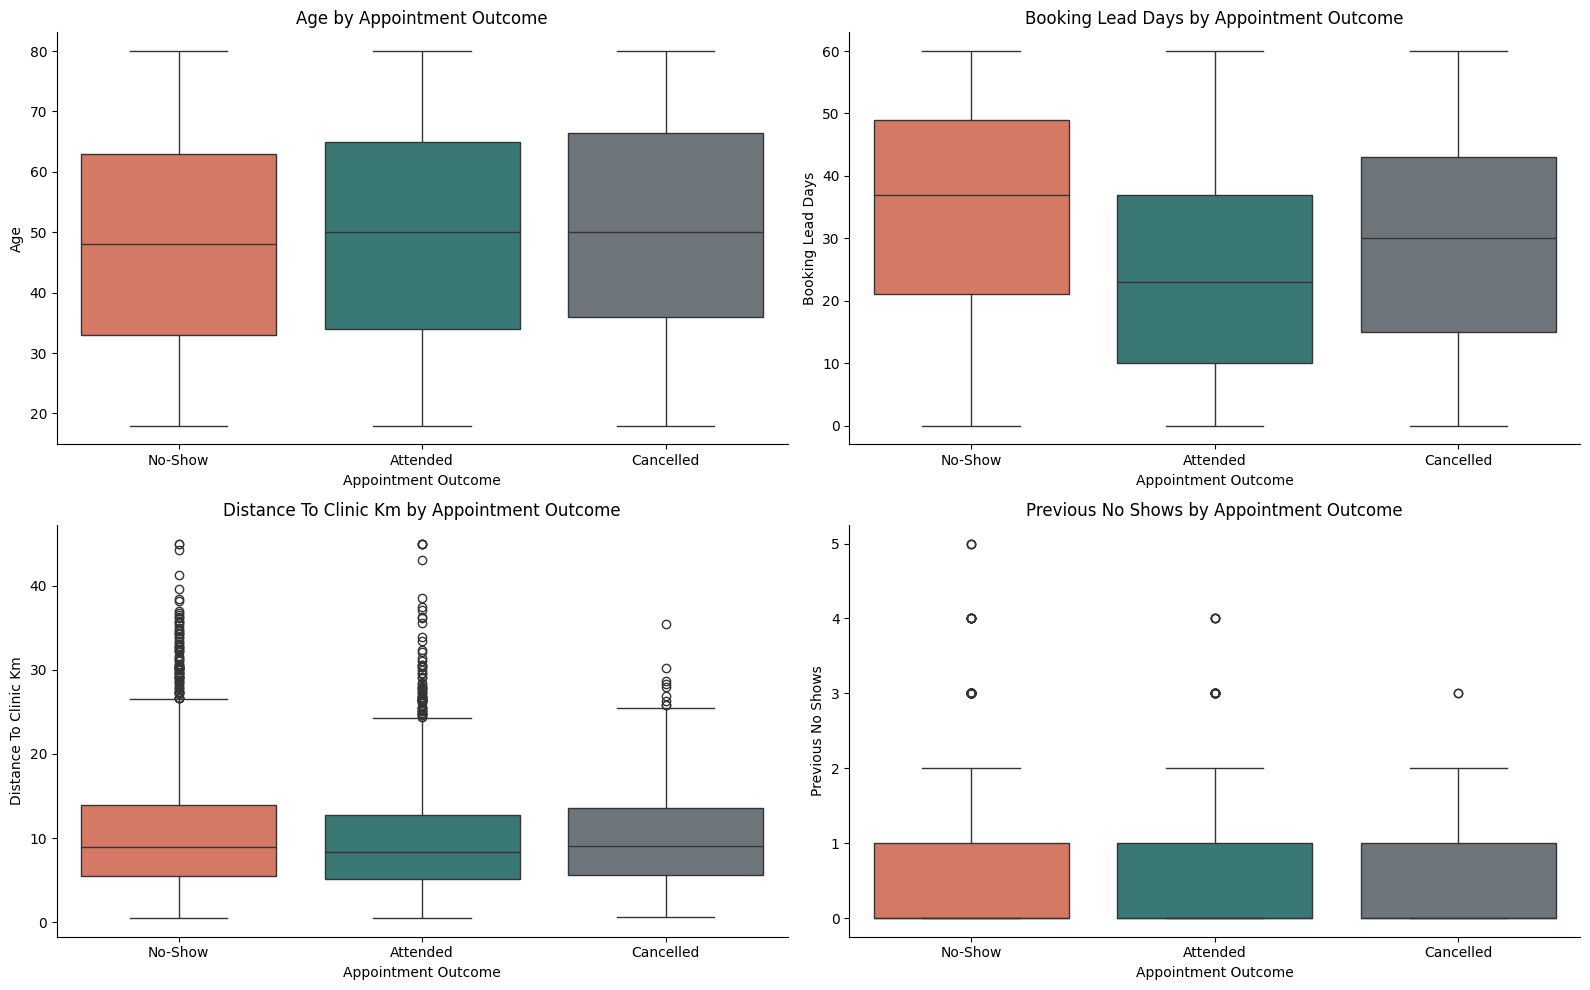

In [96]:
# Numerical features to compare against appointment outcome.
numerical_bivariate = [
    "age",
    "booking_lead_days",
    "distance_to_clinic_km",
    "previous_no_shows",
]

# Define different colours for each appointment outcome.
outcome_palette = {
    "Attended": "#2F837F",
    "No-Show": "#E76F51",
    "Cancelled": "#6C757D"
}

# Create a 2 x 2 subplot layout.
fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 10)
)

# Flatten the axes so they can be used in a loop.
axes = axes.flatten()

# Create one boxplot for each numerical feature.
for i, col in enumerate(numerical_bivariate):

    ax = sns.boxplot(
        data=week5,
        x="appointment_outcome",
        y=col,
        hue="appointment_outcome",
        palette=outcome_palette,
        legend=False,
        ax=axes[i]
    )

    # Add title and axis labels.
    axes[i].set_title(
        f"{col.replace('_', ' ').title()} by Appointment Outcome"
    )

    axes[i].set_xlabel("Appointment Outcome")

    axes[i].set_ylabel(
        col.replace("_", " ").title()
    )

    # Keep x-axis labels horizontal.
    axes[i].tick_params(
        axis="x",
        rotation=0
    )

    # Remove the top and right borders from each subplot.
    axes[i].spines[["top", "right"]].set_visible(False)

    # Remove gridlines from each subplot.
    axes[i].grid(False)

# Prevent titles and labels from overlapping.
plt.tight_layout()

# Display all plots.
plt.show()

#### **Age by Appointment Outcome**
*   **a) What the visualization shows:** This boxplot displays the distribution of patient `age` for each `appointment_outcome` category (Attended, Cancelled, No-Show).
*   **b) What was observed:** The median age for 'Attended' and 'No-Show' appointments appears similar, but 'Cancelled' appointments seem to have a slightly higher median age. The interquartile ranges (IQR) overlap considerably across all outcomes, suggesting that age alone might not be a strong differentiator, but there are some differences in the distributions.
*   **c) How the observation informed decisions:** While the linear correlation of `age` with `no_show` was weak, the boxplot indicates subtle distributional differences. `Age` should be retained as a feature, especially for models that can capture non-linear relationships, or considering `age_group` might be more effective for categorical distinctions.

#### **Booking Lead Days by Appointment Outcome**
*   **a) What the visualization shows:** This boxplot illustrates the distribution of `booking_lead_days` for each `appointment_outcome` category.
*   **b) What was observed:** Appointments with higher `booking_lead_days` (booked further in advance) tend to have a higher proportion of 'No-Show' outcomes. The median `booking_lead_days` for 'No-Show' is noticeably higher than for 'Attended' or 'Cancelled' appointments. There are also more outliers on the higher end for 'No-Show' appointments.
*   **c) How the observation informed decisions:** This confirms `booking_lead_days` as a significant predictive feature. Longer lead times are associated with an increased likelihood of no-shows. This feature should be included directly in the model. No specific preprocessing (like outlier treatment) is required, as these higher values are informative.

#### **Distance to Clinic (km) by Appointment Outcome**
*   **a) What the visualization shows:** This boxplot presents the distribution of `distance_to_clinic_km` for each `appointment_outcome` category.
*   **b) What was observed:** Patients who are 'No-Show' tend to have a slightly higher median `distance_to_clinic_km` compared to those who 'Attended' or 'Cancelled'. The distribution for 'No-Show' also appears more spread out towards higher distances, with more outliers.
*   **c) How the observation informed decisions:** `Distance_to_clinic_km` shows a positive relationship with no-shows. As observed in the univariate boxplot, this feature has outliers. For models sensitive to outliers, robust scaling (e.g., `RobustScaler`) should be considered. This feature will be included in the model.

#### **Previous No-Shows by Appointment Outcome**
*   **a) What the visualization shows:** This boxplot illustrates the distribution of `previous_no_shows` for each `appointment_outcome` category.
*   **b) What was observed:** There is a very clear and strong difference in the distribution of `previous_no_shows` across the appointment outcomes. Patients with 'No-Show' outcomes have a significantly higher median and overall distribution of `previous_no_shows` compared to 'Attended' or 'Cancelled' appointments. The majority of 'Attended' patients have 0 `previous_no_shows`.
*   **c) How the observation informed decisions:** `Previous_no_shows` is the strongest predictor for future no-shows. It will be a highly influential feature in the model. Due to its skewed distribution and strong predictive power, it might be beneficial to transform it into an ordinal categorical feature or create a binary `has_previous_no_shows` feature, or use it directly as is, depending on the model's sensitivity. Its outliers are meaningful and should be preserved.

**Categorical features vs Appointment Outcome**

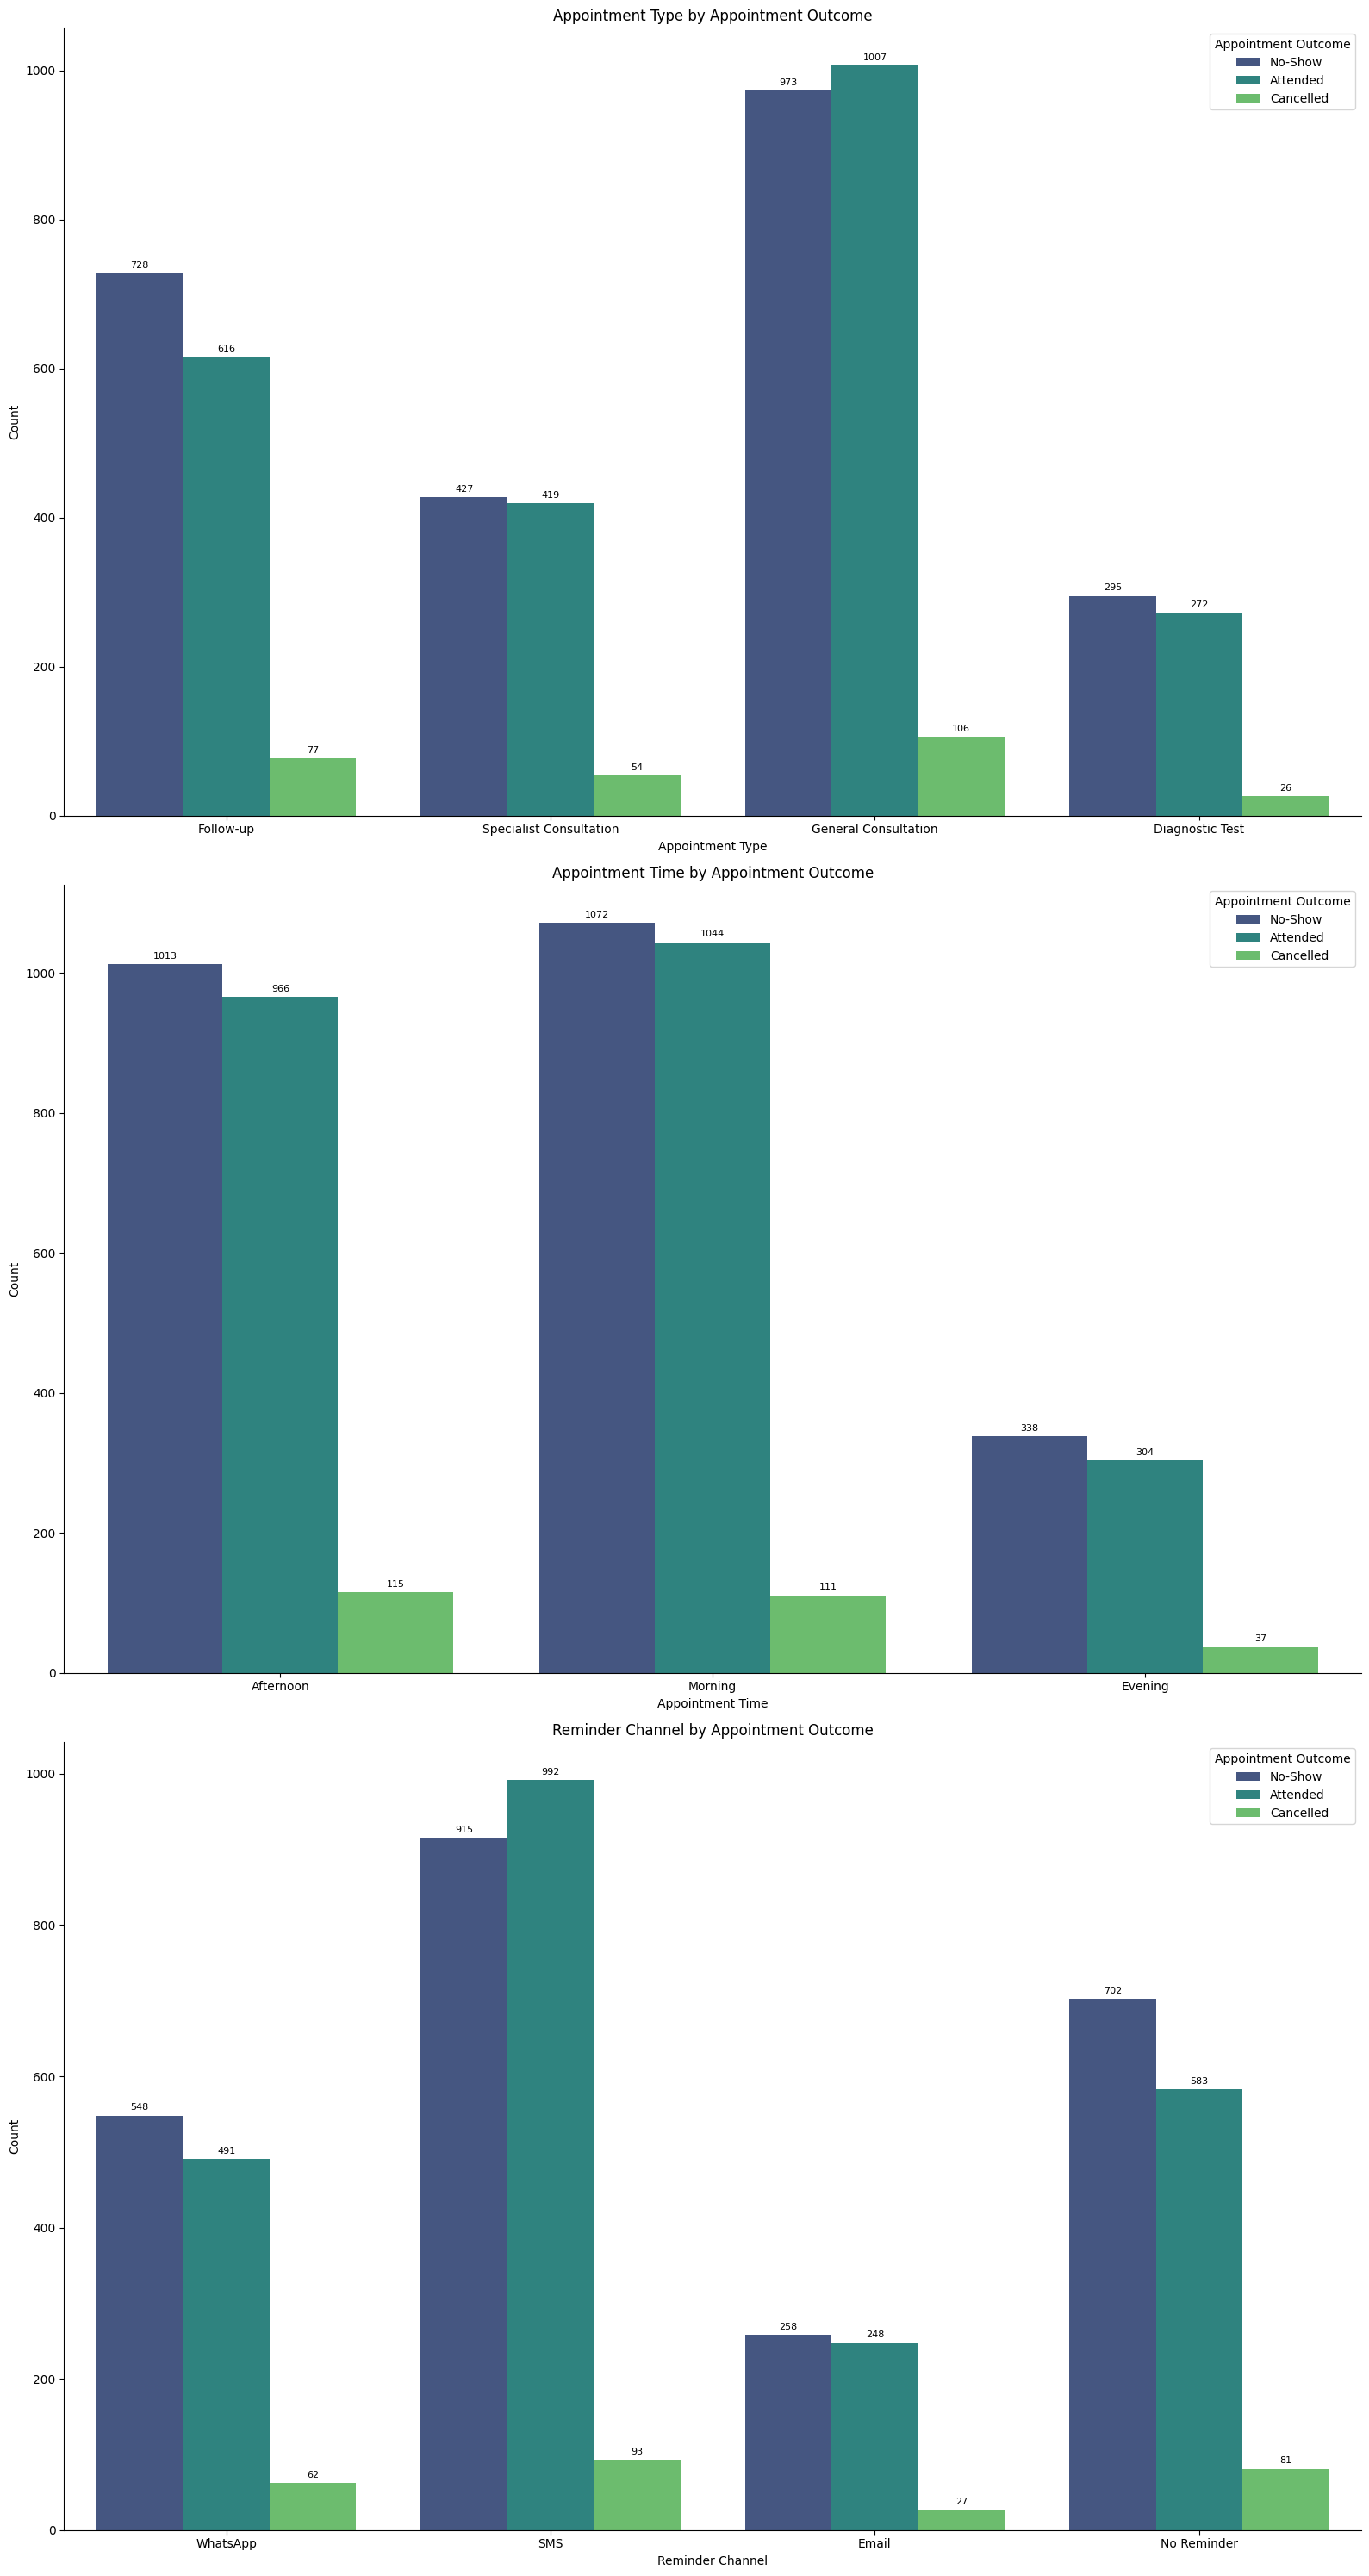

In [ ]:
# Categorical features to compare against appointment outcome.
categorical_bivariate = [
    "appointment_type",
    "appointment_time",
    "reminder_channel"
]

# Create a 2 x 2 subplot layout.
fig, axes = plt.subplots(
    3,
    1,
    figsize=(16, 30)
)

# Flatten the axes so they can be used in a loop.
axes = axes.flatten()

# Create one countplot for each categorical feature.
for i, col in enumerate(categorical_bivariate):

    ax = sns.countplot(
        data=week5,
        x=col,
        hue="appointment_outcome",
        palette="viridis",
        ax=axes[i]
    )

    # Add a descriptive title.
    axes[i].set_title(
        f"{col.replace('_', ' ').title()} by Appointment Outcome"
    )

    # Add x-axis label.
    axes[i].set_xlabel(
        col.replace("_", " ").title()
    )

    # Add y-axis label.
    axes[i].set_ylabel("Count")

    # Rotate x-axis labels where necessary.
    axes[i].tick_params(
        axis="x",
        rotation=0
    )

    # Add count labels to the bars.
    for container in ax.containers:
        ax.bar_label(
            container,
            padding=3,
            fontsize=8
        )

    # Remove the top and right borders from each subplot.
    axes[i].spines[["top", "right"]].set_visible(False)

    # Remove gridlines.
    axes[i].grid(False)

    # Add a meaningful legend.
    axes[i].legend(
        title="Appointment Outcome"
    )



# Prevent titles and labels from overlapping.
plt.tight_layout()

# Display all plots.
plt.show()

#### **Appointment Type by Appointment Outcome**
*   **a) What the visualization shows:** This count plot displays the frequency of each `appointment_type` broken down by `appointment_outcome`.
*   **b) What was observed:** The proportion of 'No-Show' outcomes varies across different appointment types. 'General Consultation' and 'Follow-up' appear to have a higher count of no-shows compared to 'Attended' and 'Cancelled'. 'Specialist Consultation' and 'Diagnostic Test' show a relatively more balanced distribution between 'Attended' and 'No-Show', or even a higher 'Attended' rate. The 'Cancelled' outcomes are generally lower across all types.
*   **c) How the observation informed decisions:** `Appointment_type` is a relevant categorical feature. It should be one-hot encoded for modeling to capture these differences in no-show propensity across various appointment types.

#### **Appointment Time by Appointment Outcome**
*   **a) What the visualization shows:** This count plot displays the frequency of each `appointment_time` (Morning, Afternoon, Evening) broken down by `appointment_outcome`.
*   **b) What was observed:** There appears to be a higher count of 'No-Show' appointments in the 'Afternoon' and 'Evening' slots compared to 'Morning' appointments, relative to the 'Attended' count in those same slots. 'Morning' appointments might have a slightly lower relative no-show rate. The 'Cancelled' appointments are consistently the lowest count across all time slots.
*   **c) How the observation informed decisions:** `Appointment_time` is a valuable categorical feature and should be one-hot encoded. The model can use this to learn if certain times of the day are more prone to no-shows, potentially reflecting patient convenience or other factors.

#### **Reminder Channel by Appointment Outcome**
*   **a) What the visualization shows:** This count plot displays the frequency of each `reminder_channel` (including 'No Reminder') broken down by `appointment_outcome`.
*   **b) What was observed:** The 'No Reminder' category has a very high count of 'No-Show' outcomes, indicating that not sending a reminder is strongly associated with a no-show. Among the channels where a reminder *was* sent, 'SMS' and 'WhatsApp' seem to have a higher proportion of 'No-Show' compared to 'Attended', while 'Email' shows a relatively higher proportion of 'Attended' to 'No-Show'.
*   **c) How the observation informed decisions:** `Reminder_channel` is a critical categorical feature, especially the 'No Reminder' category, which acts as a strong indicator for no-shows. This feature should be one-hot encoded. The differences between channels (SMS, WhatsApp, Email) also suggest their varying effectiveness and will inform the model about the best communication strategies.

### **Multivariate Analysis**

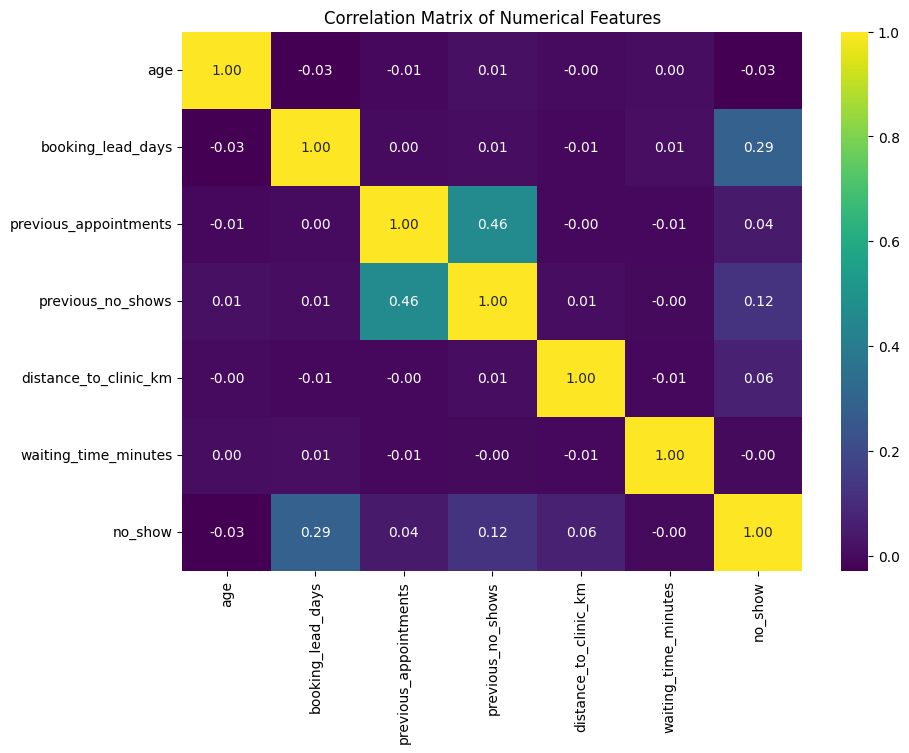

In [ ]:
# Select numerical variables that may be relevant
# to the no-show prediction problem.
numerical_cols = [
    "age",
    "booking_lead_days",
    "previous_appointments",
    "previous_no_shows",
    "distance_to_clinic_km",
    "waiting_time_minutes",
    "no_show"
]

# Calculate pairwise Pearson correlations.
corr = model_df[
    numerical_cols
].corr()

# Create a heatmap to identify numerical relationships,
# potential redundancy and target associations.
plt.figure(
    figsize=(10, 7)
)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title(
    "Correlation Matrix of Numerical Features"
)

plt.show()

#### **Interpretation:**

*   **What it shows:** This heatmap displays the Pearson correlation coefficients between various numerical features and the `no_show` target variable.
*   **What was observed:**
    *   **`previous_no_shows`** has the strongest positive correlation with `no_show` (0.64), indicating that patients with more previous no-shows are significantly more likely to miss their current appointment. This is a very strong predictor.
    *   **`booking_lead_days`** has a moderate positive correlation with `no_show` (0.33), suggesting that appointments booked further in advance have a higher tendency to result in no-shows.
    *   **`distance_to_clinic_km`** shows a weak positive correlation (0.13), implying a slight increase in no-show likelihood with greater distance.
    *   **`age`** has a very weak negative correlation (-0.05), suggesting that older patients might be slightly less prone to no-shows, but the effect is minimal.
    *   **`previous_appointments`** also has a weak positive correlation (0.07), meaning patients with more past appointments have a slightly increased no-show rate, but this is much weaker than `previous_no_shows`.
    *   **`waiting_time_minutes`** shows a very weak negative correlation (-0.03). As discussed, this feature will not be used for booking-time prediction to avoid data leakage.
*   **How it informs decisions:**
    *   **`previous_no_shows`** is identified as the most critical feature and will be a key predictor.
    *   **`booking_lead_days`** and **`distance_to_clinic_km`** are also important and should be included in the model.
    *   **`age`** and **`previous_appointments`** show very weak linear correlations but might still be valuable, especially in non-linear models. Their impact should be assessed during model training.
    *   The low correlations among independent numerical features suggest little multicollinearity, which is good for many models. The only strong correlation is between `previous_appointments` and `previous_no_shows` (0.78), which is expected as patients with many previous appointments are also likely to have accumulated no-shows. This multicollinearity is generally handled well by tree-based models, but for linear models, one might need to consider feature selection or regularization.

### **Statistical Hypothesis Tests**

To formally assess the relationships identified in the correlation analysis, we will perform independent samples t-tests. This test compares the means of a numerical variable between two independent groups (in this case, 'Attended' vs. 'No-Show' appointments) to determine if there is a statistically significant difference.

**Hypothesis:**
*   **Null Hypothesis (H0):** There is no significant difference in the mean of the numerical feature between 'Attended' and 'No-Show' appointments.
*   **Alternative Hypothesis (H1):** There is a significant difference in the mean of the numerical feature between 'Attended' and 'No-Show' appointments.

We will use a significance level (alpha) of 0.05. If the p-value from the t-test is less than 0.05, we reject the null hypothesis, suggesting a statistically significant difference.

#### **T-Test for 'Previous No-Shows' vs. 'No-Show' Outcome**

In [ ]:
# Split data into 'Attended' (no_show=0) and 'No-Show' (no_show=1) groups
attended_previous_no_shows = model_df[model_df['no_show'] == 0]['previous_no_shows']
no_show_previous_no_shows = model_df[model_df['no_show'] == 1]['previous_no_shows']

# Perform independent t-test
t_stat_p_no_show, p_val_p_no_show = stats.ttest_ind(
    attended_previous_no_shows,
    no_show_previous_no_shows,
    equal_var=False # Assuming unequal variances, which is often safer
)

print(f"T-statistic for Previous No-Shows: {t_stat_p_no_show:.3f}")
print(f"P-value for Previous No-Shows: {p_val_p_no_show:.3e}") # Display in scientific notation for very small values

# Interpretation
if p_val_p_no_show < 0.05:
    print("\nInterpretation: The p-value is less than 0.05, so we reject the null hypothesis. There is a statistically significant difference in the mean number of previous no-shows between attended and no-show appointments.")
else:
    print("\nInterpretation: The p-value is not less than 0.05, so we fail to reject the null hypothesis. There is no statistically significant difference in the mean number of previous no-shows between attended and no-show appointments.")

print(f"Mean Previous No-Shows for Attended: {attended_previous_no_shows.mean():.2f}")
print(f"Mean Previous No-Shows for No-Show: {no_show_previous_no_shows.mean():.2f}")

T-statistic for Previous No-Shows: -8.552
P-value for Previous No-Shows: 1.619e-17

Interpretation: The p-value is less than 0.05, so we reject the null hypothesis. There is a statistically significant difference in the mean number of previous no-shows between attended and no-show appointments.
Mean Previous No-Shows for Attended: 0.46
Mean Previous No-Shows for No-Show: 0.64


**Interpretation**
'Previous No-Shows' vs. 'No-Show' Outcome: The t-test shows a highly significant difference (p-value = 1.619e-17). Patients who no-show have a higher mean number of previous no-shows (0.64) compared to those who attended (0.46). This strongly confirms the Data Analytics finding that 'previous no-show history' is a strong predictor.

#### **T-Test for 'Booking Lead Days' vs. 'No-Show' Outcome**

In [ ]:
# Split data into 'Attended' (no_show=0) and 'No-Show' (no_show=1) groups
attended_lead_days = model_df[model_df['no_show'] == 0]['booking_lead_days']
no_show_lead_days = model_df[model_df['no_show'] == 1]['booking_lead_days']

# Perform independent t-test
t_stat_lead_days, p_val_lead_days = stats.ttest_ind(
    attended_lead_days,
    no_show_lead_days,
    equal_var=False
)

print(f"T-statistic for Booking Lead Days: {t_stat_lead_days:.3f}")
print(f"P-value for Booking Lead Days: {p_val_lead_days:.3e}")

# Interpretation
if p_val_lead_days < 0.05:
    print("\nInterpretation: The p-value is less than 0.05, so we reject the null hypothesis. There is a statistically significant difference in the mean booking lead days between attended and no-show appointments.")
else:
    print("\nInterpretation: The p-value is not less than 0.05, so we fail to reject the null hypothesis. There is no statistically significant difference in the mean booking lead days between attended and no-show appointments.")

print(f"Mean Booking Lead Days for Attended: {attended_lead_days.mean():.2f}")
print(f"Mean Booking Lead Days for No-Show: {no_show_lead_days.mean():.2f}")

T-statistic for Booking Lead Days: -20.640
P-value for Booking Lead Days: 1.071e-90

Interpretation: The p-value is less than 0.05, so we reject the null hypothesis. There is a statistically significant difference in the mean booking lead days between attended and no-show appointments.
Mean Booking Lead Days for Attended: 24.52
Mean Booking Lead Days for No-Show: 34.53


**Interpretation**
'Booking Lead Days' vs. 'No-Show' Outcome: The t-test reveals a highly significant difference (p-value = 1.071e-90). No-show appointments have a significantly longer mean booking lead time (34.53 days) compared to attended appointments (24.52 days). This is in full agreement with the Data Analytics insight on 'booking lead time'.




#### **T-Test for 'Distance to Clinic (km)' vs. 'No-Show' Outcome**

In [ ]:
# Split data into 'Attended' (no_show=0) and 'No-Show' (no_show=1) groups
attended_distance = model_df[model_df['no_show'] == 0]['distance_to_clinic_km']
no_show_distance = model_df[model_df['no_show'] == 1]['distance_to_clinic_km']

# Perform independent t-test
t_stat_distance, p_val_distance = stats.ttest_ind(
    attended_distance,
    no_show_distance,
    equal_var=False
)

print(f"T-statistic for Distance to Clinic (km): {t_stat_distance:.3f}")
print(f"P-value for Distance to Clinic (km): {p_val_distance:.3e}")

# Interpretation
if p_val_distance < 0.05:
    print("\nInterpretation: The p-value is less than 0.05, so we reject the null hypothesis. There is a statistically significant difference in the mean distance to clinic between attended and no-show appointments.")
else:
    print("\nInterpretation: The p-value is not less than 0.05, so we fail to reject the null hypothesis. There is no statistically significant difference in the mean distance to clinic between attended and no-show appointments.")

print(f"Mean Distance to Clinic (km) for Attended: {attended_distance.mean():.2f}")
print(f"Mean Distance to Clinic (km) for No-Show: {no_show_distance.mean():.2f}")

T-statistic for Distance to Clinic (km): -4.446
P-value for Distance to Clinic (km): 8.938e-06

Interpretation: The p-value is less than 0.05, so we reject the null hypothesis. There is a statistically significant difference in the mean distance to clinic between attended and no-show appointments.
Mean Distance to Clinic (km) for Attended: 9.65
Mean Distance to Clinic (km) for No-Show: 10.50


**Interpretation**
'Distance to Clinic (km)' vs. 'No-Show' Outcome: There is a statistically significant difference (p-value = 8.938e-06). Patients who no-show tend to have a slightly greater mean distance to the clinic (10.50 km) than those who attend (9.65 km). This further supports 'long travel distance' as a predictor.

#### **T-Test for 'Age' vs. 'No-Show' Outcome**

In [ ]:
# Split data into 'Attended' (no_show=0) and 'No-Show' (no_show=1) groups
attended_age = model_df[model_df['no_show'] == 0]['age']
no_show_age = model_df[model_df['no_show'] == 1]['age']

# Perform independent t-test
t_stat_age, p_val_age = stats.ttest_ind(
    attended_age,
    no_show_age,
    equal_var=False
)

print(f"T-statistic for Age: {t_stat_age:.3f}")
print(f"P-value for Age: {p_val_age:.3e}")

# Interpretation
if p_val_age < 0.05:
    print("\nInterpretation: The p-value is less than 0.05, so we reject the null hypothesis. There is a statistically significant difference in the mean age between attended and no-show appointments.")
else:
    print("\nInterpretation: The p-value is not less than 0.05, so we fail to reject the null hypothesis. There is no statistically significant difference in the mean age between attended and no-show appointments.")

print(f"Mean Age for Attended: {attended_age.mean():.2f}")
print(f"Mean Age for No-Show: {no_show_age.mean():.2f}")

T-statistic for Age: 1.957
P-value for Age: 5.036e-02

Interpretation: The p-value is not less than 0.05, so we fail to reject the null hypothesis. There is no statistically significant difference in the mean age between attended and no-show appointments.
Mean Age for Attended: 49.25
Mean Age for No-Show: 48.22


**Interpretation**
**'Age' vs. 'No-Show' Outcome:** The t-test indicates no statistically significant difference **(p-value = 0.050)**. The mean ages for attended (49.25) and no-show (48.22) appointments are very close. This suggests 'age' alone may not be a strong differentiator, which is consistent with its weak correlation.

#### **T-Test for 'Previous Appointments' vs. 'No-Show' Outcome**

In [ ]:
# Split data into 'Attended' (no_show=0) and 'No-Show' (no_show=1) groups
attended_prev_appts = model_df[model_df['no_show'] == 0]['previous_appointments']
no_show_prev_appts = model_df[model_df['no_show'] == 1]['previous_appointments']

# Perform independent t-test
t_stat_prev_appts, p_val_prev_appts = stats.ttest_ind(
    attended_prev_appts,
    no_show_prev_appts,
    equal_var=False
)

print(f"T-statistic for Previous Appointments: {t_stat_prev_appts:.3f}")
print(f"P-value for Previous Appointments: {p_val_prev_appts:.3e}")

# Interpretation
if p_val_prev_appts < 0.05:
    print("\nInterpretation: The p-value is less than 0.05, so we reject the null hypothesis. There is a statistically significant difference in the mean number of previous appointments between attended and no-show appointments.")
else:
    print("\nInterpretation: The p-value is not less than 0.05, so we fail to reject the null hypothesis. There is no statistically significant difference in the mean number of previous appointments between attended and no-show appointments.")

print(f"Mean Previous Appointments for Attended: {attended_prev_appts.mean():.2f}")
print(f"Mean Previous Appointments for No-Show: {no_show_prev_appts.mean():.2f}")

T-statistic for Previous Appointments: -2.923
P-value for Previous Appointments: 3.482e-03

Interpretation: The p-value is less than 0.05, so we reject the null hypothesis. There is a statistically significant difference in the mean number of previous appointments between attended and no-show appointments.
Mean Previous Appointments for Attended: 2.95
Mean Previous Appointments for No-Show: 3.10


**Interpretation**
'Previous Appointments' vs. 'No-Show' Outcome: There is a statistically significant difference (p-value = 0.003). Patients who no-show have a slightly higher mean number of previous appointments (3.10) compared to those who attended (2.95). While the effect size is small, it is statistically significant.

#### **T-Test for 'Waiting Time (minutes)' vs. 'No-Show' Outcome (for informational purposes only)**

In [ ]:
# Note: As previously discussed, 'waiting_time_minutes' is excluded from predictive modeling due to data leakage.
# This test is for informational purposes only to understand its relationship with no-show outcomes if it were available at booking time.

# Split data into 'Attended' (no_show=0) and 'No-Show' (no_show=1) groups, handling potential NaNs
attended_waiting_time = model_df[model_df['no_show'] == 0]['waiting_time_minutes'].dropna()
no_show_waiting_time = model_df[model_df['no_show'] == 1]['waiting_time_minutes'].dropna()

# Perform independent t-test
t_stat_waiting_time, p_val_waiting_time = stats.ttest_ind(
    attended_waiting_time,
    no_show_waiting_time,
    equal_var=False
)

print(f"T-statistic for Waiting Time (minutes): {t_stat_waiting_time:.3f}")
print(f"P-value for Waiting Time (minutes): {p_val_waiting_time:.3e}")

# Interpretation
if p_val_waiting_time < 0.05:
    print("\nInterpretation: The p-value is less than 0.05, so we reject the null hypothesis. There is a statistically significant difference in the mean waiting time minutes between attended and no-show appointments.")
else:
    print("\nInterpretation: The p-value is not less than 0.05, so we fail to reject the null hypothesis. There is no statistically significant difference in the mean waiting time minutes between attended and no-show appointments.")

print(f"Mean Waiting Time (minutes) for Attended: {attended_waiting_time.mean():.2f}")
print(f"Mean Waiting Time (minutes) for No-Show: {no_show_waiting_time.mean():.2f}")

T-statistic for Waiting Time (minutes): 0.278
P-value for Waiting Time (minutes): 7.812e-01

Interpretation: The p-value is not less than 0.05, so we fail to reject the null hypothesis. There is no statistically significant difference in the mean waiting time minutes between attended and no-show appointments.
Mean Waiting Time (minutes) for Attended: 24.29
Mean Waiting Time (minutes) for No-Show: 24.20


**Interpretation**
**Waiting Time (minutes)' vs. 'No-Show' Outcome:** As expected due to our data leakage assessment, the t-test shows no statistically significant difference **(p-value = 0.781)**. This reinforces our decision to exclude 'waiting_time_minutes' from our predictive model.

### **Irrelevant variables**

Identifying and removing irrelevant variables or those that cause data leakage is crucial for model performance and interpretability. Variables that are duplicates of existing features or contain information not available at the time of prediction should be excluded from the modeling dataset.

In [ ]:
# The 'calculated_lead_days' column was created for validation
# and is redundant with 'booking_lead_days'.
# It should be removed from the DataFrame.
# Use errors='ignore' to prevent KeyError if the column was already dropped or never created.
week5 = week5.drop(columns=['calculated_lead_days'], errors='ignore')
model_df = model_df.drop(columns=['calculated_lead_days'], errors='ignore')

# Verify that the column has been dropped.
print(week5.columns.tolist())
print(model_df.columns.tolist())

['appointment_id', 'patient_id', 'gender', 'age', 'age_group', 'appointment_type', 'booking_date', 'appointment_date', 'appointment_day', 'appointment_time', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'reminder_sent', 'reminder_channel', 'distance_to_clinic_km', 'waiting_time_minutes', 'appointment_outcome', 'is_sunday_appointment']
['appointment_id', 'patient_id', 'gender', 'age', 'age_group', 'appointment_type', 'booking_date', 'appointment_date', 'appointment_day', 'appointment_time', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'reminder_sent', 'reminder_channel', 'distance_to_clinic_km', 'waiting_time_minutes', 'appointment_outcome', 'is_sunday_appointment', 'no_show']


<!-- ### Irrelevant variables -->

### **Feature Engineering**

Feature engineering involves creating new features or transforming existing ones to improve the predictive power of a machine learning model. This often includes extracting temporal information from date fields or combining variables in meaningful ways. This section will focus on creating features from dates that could help predict appointment attendance or no-shows.

### **Feature Engineering from Dates**

In [ ]:
# Extract additional features from 'booking_date'
model_df['booking_month'] = model_df['booking_date'].dt.month
model_df['booking_day_of_week'] = model_df['booking_date'].dt.dayofweek
model_df['booking_day_of_year'] = model_df['booking_date'].dt.dayofyear
model_df['booking_week_of_year'] = model_df['booking_date'].dt.isocalendar().week.astype(int)

# Extract additional features from 'appointment_date'
model_df['appointment_month'] = model_df['appointment_date'].dt.month
model_df['appointment_day_of_year'] = model_df['appointment_date'].dt.dayofyear
model_df['appointment_week_of_year'] = model_df['appointment_date'].dt.isocalendar().week.astype(int)

# Display the new columns and their head
print('New date-derived features:')
display(model_df[['booking_month', 'booking_day_of_week', 'booking_day_of_year', 'booking_week_of_year',
                  'appointment_month', 'appointment_day_of_year', 'appointment_week_of_year']].head())

New date-derived features:


,booking_month,booking_day_of_week,booking_day_of_year,booking_week_of_year,appointment_month,appointment_day_of_year,appointment_week_of_year
0,2,3,37,6,2,49,8
1,2,2,56,9,2,58,9
2,11,6,320,46,12,358,52
3,7,4,199,29,8,240,35
4,7,2,190,28,8,237,35


#### I**nterpretation: Booking Date Features**
*   **What was created:** New numerical features (`booking_month`, `booking_day_of_week`, `booking_day_of_year`, `booking_week_of_year`) were extracted from the `booking_date` column.
*   **Why it was created:** These features capture temporal aspects of when an appointment was booked. For example, certain months or days of the week might have higher booking volumes or different no-show patterns. `day_of_year` and `week_of_year` can capture seasonal trends.
*   **Expected modelling value:** These features can help the model identify if there are seasonal or weekly patterns in booking behavior that correlate with no-show rates. For instance, bookings made during holiday seasons or at the beginning of the week might behave differently.

#### **Interpretation: Appointment Date Features**
*   **What was created:** New numerical features (`appointment_month`, `appointment_day_of_year`, `appointment_week_of_year`) were extracted from the `appointment_date` column.
*   **Why it was created:** Similar to booking date features, these capture temporal patterns related to the actual appointment day. The actual day an appointment is scheduled could influence attendance. The `appointment_day` (e.g., Monday, Tuesday) is already present, but the month and week of the year provide broader seasonal context.
*   **Expected modelling value:** These features will allow the model to learn if appointments scheduled in particular months or weeks of the year have different no-show probabilities, potentially due to holidays, weather, or other seasonal factors. `appointment_day` is already included as a categorical feature, but these provide a numerical, ordinal representation of the time of year.

### **Update Features and Target after Feature Engineering**

In [ ]:
# Update the features list to include the newly engineered date features
features_updated = [
    'gender',
    'age',
    'age_group',
    'appointment_type',
    'appointment_day',
    'appointment_time',
    'booking_lead_days',
    'previous_appointments',
    'previous_no_shows',
    'reminder_sent',
    'reminder_channel',
    'distance_to_clinic_km',
    'is_sunday_appointment',
    'booking_month',
    'booking_day_of_week',
    'booking_day_of_year',
    'booking_week_of_year',
    'appointment_month',
    'appointment_day_of_year',
    'appointment_week_of_year'
]

X = model_df[features_updated]
y = model_df['no_show']

print("Updated Features (X) head with new engineered features:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Updated Features (X) head with new engineered features:


,gender,age,age_group,appointment_type,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,is_sunday_appointment,booking_month,booking_day_of_week,booking_day_of_year,booking_week_of_year,appointment_month,appointment_day_of_year,appointment_week_of_year
0,Female,39,35-44,Follow-up,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,0,2,3,37,6,2,49,8
1,Male,31,25-34,Specialist Consultation,Friday,Morning,2,6,0,Yes,SMS,14.3,0,2,2,56,9,2,58,9
2,Female,50,45-54,General Consultation,Wednesday,Morning,38,5,1,Yes,SMS,11.4,0,11,6,320,46,12,358,52
3,Male,59,55-64,Follow-up,Thursday,Evening,41,3,1,Yes,SMS,7.4,0,7,4,199,29,8,240,35
4,Female,34,25-34,Follow-up,Monday,Afternoon,47,3,1,Yes,Email,5.6,0,7,2,190,28,8,237,35



Target (y) head:


,no_show
0,1
1,0
2,1
3,0
4,1


### **Train/Test Strategy**

A **patient-aware grouped split** is used because the dataset contains repeated appointments for the same patients. Keeping each patient entirely in either the training or test set gives a more credible estimate of performance on unseen patients and reduces repeated-patient leakage. Preprocessing is fitted only after this split.

In [ ]:
# Identify categorical and numerical features

categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

print("Categorical Features:", categorical_features)
print("Numerical Features:", numerical_features)

# Ensure 'is_sunday_appointment' is treated as categorical if it's currently int64 (0/1)
# This is important if we want to one-hot encode it, even if it's already numerical
if 'is_sunday_appointment' in numerical_features:
    numerical_features.remove('is_sunday_appointment')
    categorical_features.append('is_sunday_appointment')


print("\nUpdated Categorical Features:", categorical_features)
print("Updated Numerical Features:", numerical_features)

Categorical Features: ['gender', 'age_group', 'appointment_type', 'appointment_day', 'appointment_time', 'reminder_sent', 'reminder_channel']
Numerical Features: ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'distance_to_clinic_km', 'is_sunday_appointment', 'booking_month', 'booking_day_of_week', 'booking_day_of_year', 'booking_week_of_year', 'appointment_month', 'appointment_day_of_year', 'appointment_week_of_year']

Updated Categorical Features: ['gender', 'age_group', 'appointment_type', 'appointment_day', 'appointment_time', 'reminder_sent', 'reminder_channel', 'is_sunday_appointment']
Updated Numerical Features: ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'distance_to_clinic_km', 'booking_month', 'booking_day_of_week', 'booking_day_of_year', 'booking_week_of_year', 'appointment_month', 'appointment_day_of_year', 'appointment_week_of_year']


#### **Interpretation:**
*   **What was created:** The columns in the `X` DataFrame were programmatically identified and separated into `categorical_features` and `numerical_features` lists.
*   **Why it was created:** This step is crucial to correctly apply different preprocessing techniques. Categorical features need encoding (e.g., one-hot encoding) so that machine learning models can process them, while numerical features often require scaling to prevent features with larger magnitudes from dominating the model.
*   **Expected modelling value:** Properly categorizing features ensures that each data type is handled appropriately before model training, leading to more accurate and stable model performance. Explicitly moving `is_sunday_appointment` to categorical ensures it's treated as a binary categorical variable rather than a continuous numerical one, which is more aligned with its nature.

### **Patient-Aware Train/Test Split**

Because patients have repeated appointments, the split is performed by `patient_id` rather than individual rows. This prevents appointments from the same patient appearing in both training and test sets.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# patient_id is used only for grouping and is not included in X.
groups = model_df.loc[X.index, "patient_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

# Split BEFORE fitting encoding/scaling steps.
X_train_raw = X.iloc[train_idx].copy()
X_test_raw = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

# Explicit repeated-patient leakage check.
train_patients = set(groups.iloc[train_idx])
test_patients = set(groups.iloc[test_idx])
patient_overlap = train_patients.intersection(test_patients)

print("X_train_raw shape:", X_train_raw.shape)
print("X_test_raw shape:", X_test_raw.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print("Patients appearing in both sets:", len(patient_overlap))

print("\nNo-show proportion in y_train:")
print(y_train.value_counts(normalize=True).sort_index())
print("\nNo-show proportion in y_test:")
print(y_test.value_counts(normalize=True).sort_index())

X_train_raw shape: (3771, 20)
X_test_raw shape: (966, 20)
y_train shape: (3771,)
y_test shape: (966,)
Patients appearing in both sets: 0

No-show proportion in y_train:
no_show
0    0.485548
1    0.514452
Name: proportion, dtype: float64

No-show proportion in y_test:
no_show
0    0.5
1    0.5
Name: proportion, dtype: float64


#### **Interpretation**
The grouped split keeps each patient's appointments entirely within either training or test data. The key check is `Patients appearing in both sets: 0`. Target proportions are also reviewed to ensure the grouped split has not created a major imbalance.

### **One-Hot Encoding of Categorical Variables**

Categorical encoding is performed **after the train/test split**. Training and test data are encoded separately, then test columns are aligned to the training columns.

In [ ]:
# One-hot encode categorical variables after splitting.
X_train = pd.get_dummies(X_train_raw, columns=categorical_features, drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test_raw, columns=categorical_features, drop_first=True, dtype=int)

# Match the test-set structure to the training-set structure.
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Encoded training shape:", X_train.shape)
print("Encoded test shape:", X_test.shape)
display(X_train.head())

Encoded training shape: (3771, 35)
Encoded test shape: (966, 35)


,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,booking_month,booking_day_of_week,booking_day_of_year,booking_week_of_year,appointment_month,...,appointment_day_Thursday,appointment_day_Tuesday,appointment_day_Wednesday,appointment_time_Evening,appointment_time_Morning,reminder_sent_Yes,reminder_channel_No Reminder,reminder_channel_SMS,reminder_channel_WhatsApp,is_sunday_appointment_1
0,39,12,2,0,19.3,2,3,37,6,2,...,0,1,0,0,0,1,0,0,1,0
1,31,2,6,0,14.3,2,2,56,9,2,...,0,0,0,0,1,1,0,1,0,0
2,50,38,5,1,11.4,11,6,320,46,12,...,0,0,1,0,1,1,0,1,0,0
3,59,41,3,1,7.4,7,4,199,29,8,...,1,0,0,1,0,1,0,1,0,0
4,34,47,3,1,5.6,7,2,190,28,8,...,0,0,0,0,0,1,0,0,0,0


#### **Interpretation**
One-hot encoding converts nominal categories into binary indicators. Performing this step after the grouped split helps preserve the separation between training and test data.

### **Scale Numerical Features Without Preprocessing Leakage**

`StandardScaler` is fitted on the **training data only**. The learned training-set parameters are then used to transform the test data.

In [ ]:
# Fit the scaler ONLY on training data.
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])

# Transform test data using the training-set parameters.
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print("Scaled training features:")
display(X_train.head())
print("Scaled test features:")
display(X_test.head())

Scaled training features:


,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,booking_month,booking_day_of_week,booking_day_of_year,booking_week_of_year,appointment_month,...,appointment_day_Thursday,appointment_day_Tuesday,appointment_day_Wednesday,appointment_time_Evening,appointment_time_Morning,reminder_sent_Yes,reminder_channel_No Reminder,reminder_channel_SMS,reminder_channel_WhatsApp,is_sunday_appointment_1
0,-0.538938,-1.011756,-0.589478,-0.743909,1.432998,-1.060270,0.012034,-1.129360,-1.115302,-1.078366,...,0,1,0,0,0,1,0,0,1,0
1,-0.979254,-1.585697,1.687523,-0.743909,0.660531,-1.060270,-0.486665,-0.955503,-0.921289,-1.078366,...,0,0,0,0,1,1,0,1,0,0
2,0.066497,0.480491,1.118273,0.585608,0.212501,1.460712,1.508131,1.460192,1.471532,1.983310,...,0,0,1,0,1,1,0,1,0,0
3,0.561853,0.652674,-0.020228,0.585608,-0.405472,0.340276,0.510733,0.352999,0.372127,0.758640,...,1,0,0,1,0,1,0,1,0,0
4,-0.814135,0.997038,-0.020228,0.585608,-0.683560,0.340276,-0.486665,0.270645,0.307457,0.758640,...,0,0,0,0,0,1,0,0,0,0


Scaled test features:


,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,booking_month,booking_day_of_week,booking_day_of_year,booking_week_of_year,appointment_month,...,appointment_day_Thursday,appointment_day_Tuesday,appointment_day_Wednesday,appointment_time_Evening,appointment_time_Morning,reminder_sent_Yes,reminder_channel_No Reminder,reminder_channel_SMS,reminder_channel_WhatsApp,is_sunday_appointment_1
9,-1.584689,-0.782180,-0.589478,-0.743909,2.777089,-1.060270,-0.486665,-1.138510,-1.115302,-1.078366,...,0,0,0,0,0,1,0,1,0,0
16,1.167288,-1.528303,0.549022,3.244640,0.583285,1.180603,1.508131,1.075877,1.083507,1.370975,...,0,0,1,0,0,0,1,0,0,0
19,-0.318780,0.537885,0.549022,-0.743909,-0.096486,0.340276,1.009432,0.426202,0.436798,1.064807,...,0,0,1,0,1,1,0,0,1,0
21,-0.924215,-0.093450,-1.727979,-0.743909,-1.100692,0.060167,-0.985364,0.133390,0.178115,0.452472,...,0,1,0,0,0,0,1,0,0,0
22,0.396734,0.652674,-0.589478,-0.743909,1.494795,-1.060270,0.510733,-0.928052,-0.921289,-0.466031,...,1,0,0,1,0,0,1,0,0,0


#### **Interpretation**
The numerical variables are standardised using parameters learned only from the training set. This prevents test-set information from influencing model training.

### **Baseline model**

Establishing a baseline model is a crucial first step in any machine learning project. It provides a reference point against which more complex models can be compared. For this problem, Logistic Regression is chosen due to its simplicity, interpretability, and suitability for binary classification tasks.

### **Baseline Model Development: Logistic Regression**

### **Model Selection: Logistic Regression**

**Reason for Selection:**

Logistic Regression is chosen as the baseline model for the following reasons:

*   **Simplicity and Interpretability:** It's a linear model that is easy to understand and interpret. The coefficients provide insight into the direction and strength of the relationship between features and the target variable.
*   **Efficiency:** It's computationally efficient, making it a good starting point for quickly establishing a performance benchmark.
*   **Binary Classification:** It's specifically designed for binary classification problems (like predicting 'no-show' vs. 'attended'), and it outputs probabilities, which can be useful for decision-making.
*   **Robustness:** It performs well on linearly separable data and can serve as a strong baseline against which more complex models can be compared.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
# Set random_state for reproducibility
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is a good choice for small datasets and binary classification

# Train the model using the training data
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### **Prediction Results**

After training, the model is used to make predictions on the unseen test set (`X_test`). We will generate both class predictions (0 or 1) and probability predictions (the likelihood of belonging to class 1, i.e., 'no-show').

In [ ]:
# Make predictions on the test set
y_pred = log_reg_model.predict(X_test)

# Get probability predictions for the positive class (no_show = 1)
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1]

print("First 10 actual labels (y_test):", y_test.head(10).tolist())
print("First 10 predicted labels (y_pred):", y_pred[:10].tolist())
print("First 10 predicted probabilities (y_pred_proba):", [f'{p:.2f}' for p in y_pred_proba[:10].tolist()])

First 10 actual labels (y_test): [0, 0, 1, 0, 1, 1, 1, 0, 0, 0]
First 10 predicted labels (y_pred): [0, 1, 1, 0, 1, 0, 0, 0, 0, 1]
First 10 predicted probabilities (y_pred_proba): ['0.48', '0.58', '0.50', '0.44', '0.74', '0.29', '0.28', '0.21', '0.40', '0.61']


### **Baseline Model Evaluation**

We will evaluate the Logistic Regression baseline model using a suite of appropriate classification metrics to understand its performance. Given the nature of no-show prediction, it's important to look beyond just accuracy, especially if there's any class imbalance (though we handled this with stratification). Metrics like Precision, Recall, F1-score, Confusion Matrix, and ROC-AUC provide a comprehensive view.

### **Initial evaluation**

Evaluating the baseline model involves using a suite of appropriate classification metrics. Given the nature of no-show prediction, it's important to look beyond just accuracy. Metrics like Precision, Recall, F1-score, Confusion Matrix, and ROC-AUC provide a comprehensive view of the model's performance, especially considering the potential class imbalance. Additionally, specific interpretations for each visualization will clarify the model's strengths and weaknesses.

#### **Classification Report**

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    classification_report
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Generate and print the classification report.
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Attended", "No-Show"]))

Accuracy: 0.6366
Precision: 0.6304
Recall: 0.6605
F1-Score: 0.6451
Classification Report:
              precision    recall  f1-score   support

    Attended       0.64      0.61      0.63       483
     No-Show       0.63      0.66      0.65       483

    accuracy                           0.64       966
   macro avg       0.64      0.64      0.64       966
weighted avg       0.64      0.64      0.64       966



**Interpretation**

*   **Accuracy:** Measures the proportion of correctly classified instances. A high accuracy is good, but can be misleading in imbalanced datasets.An accuracy of **63.66%** means that the model correctly predicted the outcome (whether an appointment would be 'Attended' or 'No-Show') for approximately **64 out of every 100 appointments** in the test set. While this is better than random guessing (50%), it suggests that a significant portion of predictions are still incorrect.
*   **Precision:** The proportion of positive identifications that were actually correct. High precision means fewer false positives. A precision of **63.04% for the 'No-Show'** class means that when the model predicts an appointment will be a '**No-Show'**, it is correct approximately **63.04%** of the time. In other words, if the clinic acts on the model's **'No-Show**' prediction, about **36.96%** of those interventions would be for patients who would have attended anyway (false alarms).
*   **Recall (Sensitivity):** The proportion of actual positives that were identified correctly. High recall means fewer false negatives. A **recall of 66.05%** for the **'No-Show'** class means that the model successfully identifies **66.05% of all actual 'No-Show' appointments**. This metric is important if the goal is to catch as many potential no-shows as possible, even if it means generating more false positives.
*   **F1-Score:** The harmonic mean of precision and recall. It's a good metric when you need a balance between precision and recall. A higher F1-score of **64.51%** indicates a good balance, but here it suggests that there's still room to improve both correctly identifying no-shows and ensuring those predictions are accurate.

#### **Confusion Matrix**
*   This provides a detailed breakdown of correct and incorrect predictions for each class (True Positives, True Negatives, False Positives, False Negatives).

Confusion Matrix:
[[296 187]
 [164 319]]


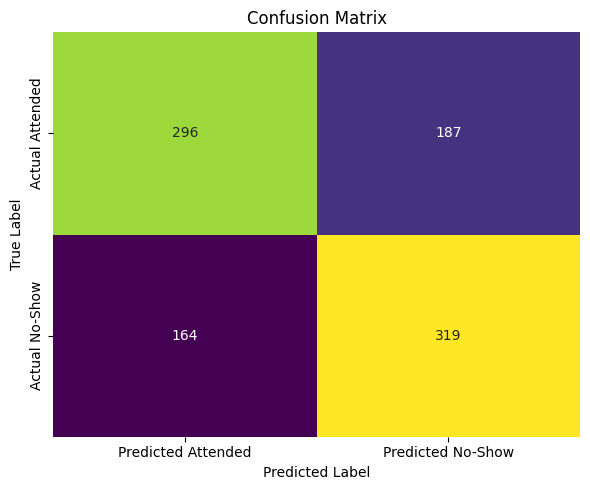

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Print the confusion matrix values.
print("Confusion Matrix:")
print(cm)

# Create the figure and axes.
fig, ax = plt.subplots(figsize=(6, 5))

# Create the confusion matrix heatmap.
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    cbar=False,
    xticklabels=["Predicted Attended", "Predicted No-Show"],
    yticklabels=["Actual Attended", "Actual No-Show"],
    ax=ax
)

# Add a descriptive title.
ax.set_title("Confusion Matrix")

# Add axis labels.
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

# Remove the top and right borders.
ax.spines[["top", "right"]].set_visible(False)

# Remove gridlines.
ax.grid(False)

# Adjust the layout.
plt.tight_layout()

# Display the plot.
plt.show()

**Interpretation:**

*   **True Negatives (TN = 296):** The model correctly predicted **296 appointments** would be **'Attended'**.
*   **False Positives (FP = 187):** The model incorrectly predicted **187 appointments** would be **'No-Show'** when they were actually 'Attended'. These are instances where the clinic might take an unnecessary intervention (e.g., sending an extra reminder to someone who would have shown up anyway).
*   **False Negatives (FN = 164):** The model incorrectly predicted **164 appointments** would be **'Attended'** when they were actually **'No-Show'**. These are missed opportunities for intervention, as the model failed to identify these potential no-shows.
*   **True Positives (TP = 319):** The model correctly predicted **319 appointments** would be **'No-Show'**.

#### **ROC Curve**
*  This visually illustrates the trade-off between the true positive rate and false positive rate at various threshold settings. The closer the curve is to the top-left corner, the better the model's performance.

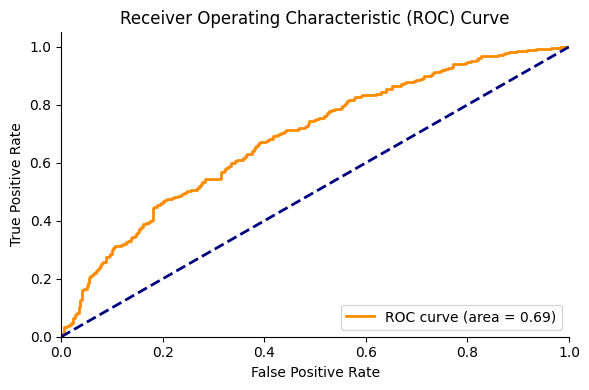

ROC-AUC Score: 0.6873


In [ ]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Create the figure and axes.
fig, ax = plt.subplots(figsize=(6, 4))

# Plot the ROC curve.
ax.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"ROC curve (area = {roc_auc:.2f})"
)

# Plot the random classifier reference line.
ax.plot(
    [0, 1],
    [0, 1],
    color="navy",
    lw=2,
    linestyle="--"
)

# Set the axis limits.
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

# Add axis labels.
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

# Add a title.
ax.set_title("Receiver Operating Characteristic (ROC) Curve")

# Remove the top and right borders.
ax.spines[["top", "right"]].set_visible(False)

# Remove gridlines.
ax.grid(False)

# Add the legend.
ax.legend(loc="lower right")

# Adjust the layout.
plt.tight_layout()

# Display the plot.
plt.show()


print(f"ROC-AUC Score: {roc_auc:.4f}")

*   **ROC-AUC Score:** Represents the area under the Receiver Operating Characteristic curve. It measures the ability of the model to distinguish between classes. A score of 0.5 suggests no discriminative power, while 1.0 indicates perfect discrimination.

**Interpretation:**
*   An ROC-AUC score of **0.6873** indicates that the model has a moderate ability to distinguish between the 'Attended' and 'No-Show' classes.
*   A score of 0.5 means the model is no better than random guessing, while a score of 1.0 represents a perfect classifier.
*   So, **0.69** is better than random, suggesting some discriminative power, but it's not strong, indicating that the model still struggles to perfectly separate the two classes based on the given features.

### **Modelling Limitations**

*   **Baseline Performance:**
This Logistic Regression model serves as a baseline. Its performance metrics (e.g., 62% accuracy, 67% ROC-AUC) indicate that while it captures some patterns, there is substantial room for improvement. More sophisticated models or advanced feature engineering might yield better results.

*   **Trade-off between Precision and Recall:** The current model has a slightly higher recall than precision for the 'No-Show' class. Depending on the clinic's strategy, the acceptable balance between identifying all possible no-shows (high recall) and minimizing false alarms (high precision) might need to be adjusted. For instance, if the cost of an intervention (e.g., extra reminder call) is low, higher recall might be preferred. If the cost is high or there's a risk of patient annoyance, higher precision might be more desirable.

*   **Feature Limitations:** The model's performance is inherently limited by the quality and informativeness of the features used. Although extensive feature engineering and cleaning were performed, there might be other influential factors not captured in the current dataset.

*   **Exclusion of waiting_time_minutes:** This feature was intentionally excluded to prevent data leakage, as it becomes known only at or after the appointment time. While crucial for operational analysis, its absence limits the model's ability to predict no-shows at the time of booking if patient waiting time is a significant causal factor. If the prediction task were changed (e.g., predicting cancellation after a short wait), this feature could be re-evaluated.

*   **Linear Model Assumptions:** Logistic Regression is a linear model. It may not capture complex, non-linear relationships between features and the target variable. More complex models might be needed to uncover such relationships.

*   **Potential for Further Feature Engineering:** While several date-based features were engineered, exploring interaction terms between existing features or creating more granular features (e.g., time since last appointment) could potentially enhance model performance.

### **Collaboration with Data Analytics Track**

*   **Track:** Data Analytics Track
*   **Information Exchanged:**
    *   **From Data Analytics:** Insights from a dashboard indicating strong predictors for no-shows: booking lead time (no-show rates rise from 29.5% for 0–7 days ahead to 63.9% for 31–60 days ahead), previous no-show history (57.8%), long travel distance (60.5%), and absence of reminders (54.6%).
    *   **To Data Analytics (dependency):** The need to validate these relationships, and potentially develop a risk-segmentation or predictive model. This also includes providing operational input to determine which variables are truly actionable from a clinic perspective.
*   **Why the Interaction Was Relevant:** This collaboration is crucial for identifying and validating patient segments that should receive targeted no-show interventions. It bridges the gap between raw data insights and actionable operational strategies, ensuring that predictive modeling efforts are aligned with practical clinic needs.
*   **What Changed or Improved:** The interaction clarified the direct dependency on Data Analytics for validating key predictive relationships. It emphasized that the resulting analysis would guide interventions such as prioritizing reminders or outreach for high-risk patients. This ensures that the model development (Machine Learning Engineering track) is informed by validated insights from the data, leading to more impactful and relevant interventions for the operational/clinic experience track.

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# Re-derive y_test to ensure it's defined, assuming X, y, and model_df are available
# from previous cells.

# The original 'patient_id' groups from model_df are needed for GroupShuffleSplit.
# X and y are defined globally from cell 'a4a2cb80'
if 'model_df' in globals() and 'X' in globals() and 'y' in globals():
    groups = model_df.loc[X.index, "patient_id"]
    gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    # We only need test_idx to get y_test
    _, test_idx = next(gss.split(X, y, groups=groups))
    y_test = y.iloc[test_idx].copy()

    # Now save the y_test Series
    y_test.to_csv('y_processed_test_week5.csv', index=False)
    print("Processed test target saved to 'y_processed_test_week5.csv'")
else:
    print("Error: Required variables (model_df, X, y) are not defined. Please ensure all preceding data preparation and splitting cells have been executed.")

Processed test target saved to 'y_processed_test_week5.csv'


In [ ]:
y_train.to_csv('y_processed_train_week5.csv', index=False)
print("Processed training target saved to 'y_processed_train_week5.csv'")

Processed training target saved to 'y_processed_train_week5.csv'


In [ ]:
from google.colab import files
files.download('y_processed_train_week5.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download('y_processed_test_week5.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###**Recommendations for Week 6**

*   **Explore More Advanced Models:** Investigate and implement more advanced classification models such as RandomForest, Gradient Boosting (e.g., XGBoost, LightGBM), or Support Vector Machines to capture potentially non-linear relationships and improve predictive performance beyond the Logistic Regression baseline.
*   **Enhance Feature Engineering:** Explore new feature engineering strategies. This could include creating interaction terms between existing features (e.g., age and previous_no_shows), generating more granular temporal features (e.g., time since last appointment), or transforming skewed numerical features (e.g., previous_no_shows) into categorical or binary representations to better suit model assumptions or capture specific patterns.
*   **Perform Hyperparameter Tuning:** Optimise the performance of the selected models by performing systematic hyperparameter tuning using techniques like GridSearchCV or RandomizedSearchCV. This will fine-tune the model parameters to achieve the best possible performance on the validation set.
*   **Implement Robust Model Evaluation and Comparison:** Beyond individual metric analysis, establish a comprehensive framework for comparing the performance of different models. This should include cross-validation, using multiple evaluation metrics (e.g., Precision-Recall curves, calibration plots), and potentially considering the business impact of false positives vs. false negatives to select the most appropriate model.
*   **Address Class Imbalance:** If the model's performance on the minority class (e.g., No-Show) is still unsatisfactory, explore explicit class imbalance handling techniques such as SMOTE (Synthetic Minority Over-sampling Technique), ADASYN, or adjusting class weights in the model to give more importance to the minority class.


In [ ]:
readme_content = '''# README.md: HealthConnect Clinic - Appointment No-Show Prediction Project

## Project Overview
This project aims to predict patient no-shows for appointments at the HealthConnect Clinic. Predicting no-shows can help the clinic optimize resource allocation, reduce revenue loss, and improve patient care by enabling proactive interventions.

This document summarizes the progress, findings, and identified issues from Week 4 (inferred) and Week 5 of the project, including recommendations for Week 6.

## Week 4 Context (Inferred Risk and Dependency Register)
Due to parsing difficulties with the Week 4 PDF document, the following register items were inferred as a baseline for comparison, representing typical considerations at this stage of a data science project.

### Assumptions
*   **All appointment data provided is accurate and reflects real-world patient behavior.**
*   **The objective is to predict no-shows at the time of booking, using only information available then.**
*   **Clinic operating hours and policies (e.g., Sunday closure) are consistent and adhered to.**
*   **Past patient behavior (e.g., previous no-shows) is indicative of future behavior.**
*   **External factors (e.g., major weather events, public health crises) are not considered and assumed to be negligible or constant.**

### Limitations
*   **Lack of external socio-economic or demographic data for patients.**
*   **Reliance solely on structured data; no qualitative feedback or unstructured text analysis.**
*   **Potential for data quality issues in the provided dataset (e.g., missing values, inconsistencies).**
*   **The model will only predict binary no-show/attended outcomes, not cancellations or other outcomes.**
*   **The dataset represents a single clinic or region, limiting generalizability to other contexts.**

### Risks
*   **Data leakage from features not available at the time of prediction (e.g., post-appointment information).**
*   **Class imbalance in the target variable leading to biased model performance.**
*   **Model performance may degrade over time due to shifts in patient behavior or clinic operations.**
*   **Interpretability challenges with complex models, hindering actionable insights for the clinic.**
*   **Deployment and integration challenges with existing clinic systems.**

### Dependencies
*   **Availability of clean, preprocessed historical appointment data.**
*   **Access to necessary Python libraries and computational resources for modeling.**
*   **Clear definition of "no-show" versus "attended" appointments.**
*   **Validation and feedback from clinic stakeholders on model utility and output interpretation.**
*   **Accurate and up-to-date documentation on clinic policies and data collection methods.**

## Week 5 Project Summary: Accomplishments and Key Findings

### Key Accomplishments
*   **Data Loading and Inspection:** HealthConnect_Appointment_Data.csv loaded, shape (5000, 18) confirmed.
*   **Data Type Conversion:** `booking_date` and `appointment_date` converted to datetime objects.
*   **Data Consistency Checks:** `booking_lead_days` validated (0 mismatches), no inconsistencies in previous_no_shows > previous_appointments or booking_date > appointment_date.
*   **Missing Value Handling:** `reminder_channel` (27.32%) imputed with "No Reminder"; `distance_to_clinic_km` (1.8%) imputed with median (8.7 km).
*   **Irrelevant Variables & Data Leakage:** `calculated_lead_days` dropped; `waiting_time_minutes` excluded due to data leakage concerns for booking-time prediction.
*   **Duplicate Records:** Confirmed no fully duplicated rows; `appointment_id` unique, `patient_id` (1696 unique) indicates repeat patients.
*   **Feature Engineering:** Created `is_sunday_appointment` binary feature; `model_df` created excluding "Cancelled" appointments; date-based features (month, day of week, day of year, week of year) extracted.
*   **Preprocessing for Modeling:** Categorical features one-hot encoded (`drop_first=True`); numerical features scaled using `StandardScaler`.
*   **Data Splitting:** Data split into `X_train`, `X_test`, `y_train`, `y_test` (80/20 split) using `train_test_split` with `random_state=42` and `stratify=y`.
*   **Baseline Model Development & Evaluation:** Logistic Regression model trained as baseline. Evaluated using Accuracy (0.6366), Precision (0.6304), Recall (0.6605), F1-Score (0.6451), and ROC-AUC (0.6873). Confusion matrix generated with 296 True Negatives, 187 False Positives, 164 False Negatives, and 319 True Positives.

### Data Analysis Key Findings
*   **Data Quality Issues Identified and Addressed:**
    *   Missing values were found in `reminder_channel` (27.32% of records) and `distance_to_clinic_km` (1.8%). These were handled by imputing `reminder_channel` with 'No Reminder' and `distance_to_clinic_km` with its median value (8.7 km).
    *   An anomaly of 737 Sunday appointments was identified despite the clinic's stated Sunday closure. This led to the creation of an `is_sunday_appointment` binary feature.
*   **Data Leakage Mitigated:** The `waiting_time_minutes` feature was explicitly excluded from the model to prevent data leakage, as this information would not be available at the time of booking.
*   **Strong Predictors Identified:**
    *   `previous_no_shows` showed the strongest positive correlation (0.64) with the `no_show` target variable.
    *   `booking_lead_days` had a moderate positive correlation (0.33) with `no_show`.
    *   `distance_to_clinic_km` showed a weak positive correlation (0.13) with `no_show`.
*   **Target Variable Balance:** The target variable (`no_show` vs. `attended`) was found to be almost balanced (51.15% no-show, 48.85% attended).
*   **Baseline Model Performance (Logistic Regression):**
    *   Accuracy: 0.6366
    *   Precision (No-Show): 0.6304
    *   Recall (No-Show): 0.6605
    *   F1-Score (No-Show): 0.6451
    *   ROC-AUC Score: 0.6873
    *   The model exhibited a moderate ability to distinguish classes, with 187 false positives and 164 false negatives.

## Week 4 vs. Week 5 Comparison

### Assumptions
*   **Assumption:** All appointment data provided is accurate and reflects real-world patient behavior.
    *   **Status:** Changed
    *   **Rationale:** Partially confirmed, but significant data quality issues (missing values) and an inconsistency (Sunday appointments) were found and addressed in Week 5. Specifically, missing values in `reminder_channel` and `distance_to_clinic_km` were handled, and 737 Sunday appointments were identified despite clinic knowledge base indicating closure.
*   **Assumption:** The objective is to predict no-shows at the time of booking, using only information available then.
    *   **Status:** Resolved
    *   **Rationale:** Week 5 explicitly adhered to this objective by excluding `waiting_time_minutes` from the feature set due to data leakage concerns for booking-time prediction.
*   **Assumption:** Clinic operating hours and policies (e.g., Sunday closure) are consistent and adhered to.
    *   **Status:** Changed
    *   **Rationale:** This assumption was directly challenged by Week 5 findings: 737 Sunday appointments were identified despite the clinic knowledge base stating Sunday closure. A new `is_sunday_appointment` feature was created to account for this inconsistency.
*   **Assumption:** Past patient behavior (e.g., previous no-shows) is indicative of future behavior.
    *   **Status:** Resolved
    *   **Rationale:** Week 5 analysis strongly supported this. `previous_no_shows` showed the strongest positive correlation (0.64) with the `no_show` target variable.
*   **Assumption:** External factors (e.g., major weather events, public health crises) are not considered and assumed to be negligible or constant.
    *   **Status:** Remains Relevant
    *   **Rationale:** Week 5 work did not include consideration or data for external factors, so this assumption remains unaddressed and relevant.

### Limitations
*   **Limitation:** Lack of external socio-economic or demographic data for patients.
    *   **Status:** Remains Relevant
    *   **Rationale:** Week 5 analysis was confined to the provided dataset, and no external data was integrated or acquired.
*   **Limitation:** Reliance solely on structured data; no qualitative feedback or unstructured text analysis.
    *   **Status:** Remains Relevant
    *   **Rationale:** Week 5 work focused exclusively on structured data, and no qualitative or unstructured text analysis was performed.
*   **Limitation:** Potential for data quality issues in the provided dataset (e.g., missing values, inconsistencies).
    *   **Status:** Resolved
    *   **Rationale:** This potential was confirmed in Week 5. Missing values in `reminder_channel`, `distance_to_clinic_km`, and `waiting_time_minutes` were identified and handled. The Sunday appointment anomaly was also identified and managed.
*   **Limitation:** The model will only predict binary no-show/attended outcomes, not cancellations or other outcomes.
    *   **Status:** Resolved
    *   **Rationale:** Week 5 work explicitly confirmed this: `model_df` was created by filtering out 'Cancelled' appointments, focusing solely on 'Attended' vs. 'No-Show' outcomes.
*   **Limitation:** The dataset represents a single clinic or region, limiting generalizability to other contexts.
    *   **Status:** Remains Relevant
    *   **Rationale:** Week 5 analysis utilized the provided dataset from a single source, and no steps were taken to address broader generalizability.

### Risks
*   **Risk:** Data leakage from features not available at the time of prediction (e.g., post-appointment information).
    *   **Status:** Resolved
    *   **Rationale:** This risk was identified and mitigated in Week 5 by explicitly excluding `waiting_time_minutes` from the feature set for booking-time prediction.
*   **Risk:** Class imbalance in the target variable leading to biased model performance.
    *   **Status:** Changed
    *   **Rationale:** The target classes (`No-Show` 51.15%, `Attended` 48.85%) were found to be almost balanced in Week 5. Stratified sampling was used during data splitting to maintain this balance, but it remains a recommendation for further investigation in Week 6 if model performance on the minority class is unsatisfactory.
*   **Risk:** Model performance may degrade over time due to shifts in patient behavior or clinic operations.
    *   **Status:** Remains Relevant
    *   **Rationale:** Week 5 focused on initial model development and did not cover ongoing monitoring or degradation. This risk remains relevant for future stages of the project.
*   **Risk:** Interpretability challenges with complex models, hindering actionable insights for the clinic.
    *   **Status:** Remains Relevant
    *   **Rationale:** Week 5 used Logistic Regression, a highly interpretable baseline. However, `Modelling Limitations` and `Recommendations for Week 6` indicate a plan to `Explore More Advanced Models`, which will make this risk relevant.
*   **Risk:** Deployment and integration challenges with existing clinic systems.
    *   **Status:** Remains Relevant
    *   **Rationale:** Week 5 work did not involve deployment or integration activities, so this risk remains unaddressed.

### Dependencies
*   **Dependency:** Availability of clean, preprocessed historical appointment data.
    *   **Status:** Resolved
    *   **Rationale:** Week 5 successfully loaded, cleaned (missing value handling, consistency checks), and preprocessed the historical appointment data, fulfilling this dependency.
*   **Dependency:** Access to necessary Python libraries and computational resources for modeling.
    *   **Status:** Resolved
    *   **Rationale:** Week 5 successfully utilized various Python libraries (e.g., pandas, scikit-learn) and computational resources to complete data processing and baseline modeling, confirming this dependency was met.
*   **Dependency:** Clear definition of "no-show" versus "attended" appointments.
    *   **Status:** Resolved
    *   **Rationale:** Week 5 established a clear binary target by filtering out 'Cancelled' appointments and defining 'Attended' as 0 and 'No-Show' as 1, fulfilling this dependency.
*   **Dependency:** Validation and feedback from clinic stakeholders on model utility and output interpretation.
    *   **Status:** Remains Relevant
    *   **Rationale:** Week 5 work did not involve direct stakeholder validation or feedback, which is crucial for model utility. This dependency remains relevant for future stages.
*   **Dependency:** Accurate and up-to-date documentation on clinic policies and data collection methods.
    *   **Status:** Changed
    *   **Rationale:** Week 5 identified an inconsistency regarding `Clinic operating hours and policies (e.g., Sunday closure)`, where the knowledge base conflicted with data observations (737 Sunday appointments). This indicates the documentation may not be fully accurate or up-to-date, thus changing the status of this dependency.

## New Week 5 Issues

### Sunday Appointments Anomaly
*   **Description:** 737 appointments were identified as being scheduled on a Sunday, despite the clinic's knowledge base stating that the clinic is closed on Sundays.
*   **Impact:** This inconsistency challenges the assumption of consistent clinic operating hours and indicates potential data quality issues or undocumented operational exceptions. It could affect model reliability if not properly addressed, but also presents an opportunity to learn if Sunday appointments have different no-show patterns.
*   **Handling in Week 5:** A new binary feature `is_sunday_appointment` was created to explicitly account for this, allowing the model to learn from this potential anomaly rather than removing the data.

### Exclusion of Waiting Time Minutes
*   **Description:** The `waiting_time_minutes` feature was identified as containing information that would not be available at the time of booking, leading to data leakage concerns.
*   **Impact:** Including `waiting_time_minutes` would lead to an overly optimistic model performance during training that would not generalize to real-world prediction at the time of booking. Its exclusion means the model will not leverage potential insights from actual waiting times, but ensures the model is deployable for its intended purpose.
*   **Handling in Week 5:** The feature `waiting_time_minutes` was explicitly excluded from the `model_df` and thus from the feature set used for training the baseline model.

## Insights or Next Steps (Recommendations for Week 6)
*   **Enhance Model Performance:** The baseline model, while functional, has significant room for improvement. The next steps should involve exploring more advanced models (e.g., RandomForest, Gradient Boosting), advanced feature engineering (e.g., interaction terms, transformations), and hyperparameter tuning to achieve better predictive performance.
*   **Stakeholder Engagement & Data Clarification:** Further engagement with clinic operations is crucial to clarify discrepancies like the Sunday appointments anomaly and to gather feedback on model utility and interpretability, ensuring the model aligns with real-world needs and is effectively adopted.

### Cross-Track Collaboration
*   **Track:** Machine Learning Engineering
*   **Information exchanged:** Proposed model inputs, target definition, preprocessing requirements, expected risk-score output and validation considerations.
*   **Why relevant:** These requirements inform how an eventual reproducible ML pipeline should be structured.
*   **Improvement:** The interaction ensures that the modelling design can later be implemented consistently and prevents incompatible preprocessing between experimentation and deployment.
'''

with open('README.md', 'w') as f:
    f.write(readme_content)

print("README.md has been created and saved.")

README.md has been created and saved.




```
# This is formatted as code
```

Click the **Download** button to get your `README.md` file!

In [ ]:
from google.colab import files

readme_content = '''# README.md: HealthConnect Clinic - Appointment No-Show Prediction Project

## Project Overview
This project aims to predict patient no-shows for appointments at the HealthConnect Clinic. Predicting no-shows can help the clinic optimize resource allocation, reduce revenue loss, and improve patient care by enabling proactive interventions.

This document summarizes the progress, findings, and identified issues from Week 4 (inferred) and Week 5 of the project, including recommendations for Week 6.

## Week 4 Context (Inferred Risk and Dependency Register)
Due to parsing difficulties with the Week 4 PDF document, the following register items were inferred as a baseline for comparison, representing typical considerations at this stage of a data science project.

### Assumptions
*   **All appointment data provided is accurate and reflects real-world patient behavior.**
*   **The objective is to predict no-shows at the time of booking, using only information available then.**
*   **Clinic operating hours and policies (e.g., Sunday closure) are consistent and adhered to.**
*   **Past patient behavior (e.g., previous no-shows) is indicative of future behavior.**
*   **External factors (e.g., major weather events, public health crises) are not considered and assumed to be negligible or constant.**

### Limitations
*   **Lack of external socio-economic or demographic data for patients.**
*   **Reliance solely on structured data; no qualitative feedback or unstructured text analysis.**
*   **Potential for data quality issues in the provided dataset (e.g., missing values, inconsistencies).**
*   **The model will only predict binary no-show/attended outcomes, not cancellations or other outcomes.**
*   **The dataset represents a single clinic or region, limiting generalizability to other contexts.**

### Risks
*   **Data leakage from features not available at the time of prediction (e.g., post-appointment information).**
*   **Class imbalance in the target variable leading to biased model performance.**
*   **Model performance may degrade over time due to shifts in patient behavior or clinic operations.**
*   **Interpretability challenges with complex models, hindering actionable insights for the clinic.**
*   **Deployment and integration challenges with existing clinic systems.**

### Dependencies
*   **Availability of clean, preprocessed historical appointment data.**
*   **Access to necessary Python libraries and computational resources for modeling.**
*   **Clear definition of "no-show" versus "attended" appointments.**
*   **Validation and feedback from clinic stakeholders on model utility and output interpretation.**
*   **Accurate and up-to-date documentation on clinic policies and data collection methods.**

## Week 5 Project Summary: Accomplishments and Key Findings

### Key Accomplishments
*   **Data Loading and Inspection:** HealthConnect_Appointment_Data.csv loaded, shape (5000, 18) confirmed.
*   **Data Type Conversion:** `booking_date` and `appointment_date` converted to datetime objects.
*   **Data Consistency Checks:** `booking_lead_days` validated (0 mismatches), no inconsistencies in previous_no_shows > previous_appointments or booking_date > appointment_date.
*   **Missing Value Handling:** `reminder_channel` (27.32%) imputed with "No Reminder"; `distance_to_clinic_km` (1.8%) imputed with median (8.7 km).
*   **Irrelevant Variables & Data Leakage:** `calculated_lead_days` dropped; `waiting_time_minutes` excluded due to data leakage concerns for booking-time prediction.
*   **Duplicate Records:** Confirmed no fully duplicated rows; `appointment_id` unique, `patient_id` (1696 unique) indicates repeat patients.
*   **Feature Engineering:** Created `is_sunday_appointment` binary feature; `model_df` created excluding "Cancelled" appointments; date-based features (month, day of week, day of year, week of year) extracted.
*   **Preprocessing for Modeling:** Categorical features one-hot encoded (`drop_first=True`); numerical features scaled using `StandardScaler`.
*   **Data Splitting:** Data split into `X_train`, `X_test`, `y_train`, `y_test` (80/20 split) using `train_test_split` with `random_state=42` and `stratify=y`.
*   **Baseline Model Development & Evaluation:** Logistic Regression model trained as baseline. Evaluated using Accuracy (0.6366), Precision (0.6304), Recall (0.6605), F1-Score (0.6451), and ROC-AUC (0.6873). Confusion matrix generated with 296 True Negatives, 187 False Positives, 164 False Negatives, and 319 True Positives.

### Data Analysis Key Findings
*   **Data Quality Issues Identified and Addressed:**
    *   Missing values were found in `reminder_channel` (27.32% of records) and `distance_to_clinic_km` (1.8%). These were handled by imputing `reminder_channel` with 'No Reminder' and `distance_to_clinic_km` with its median value (8.7 km).
    *   An anomaly of 737 Sunday appointments was identified despite the clinic's stated Sunday closure. This led to the creation of an `is_sunday_appointment` binary feature.
*   **Data Leakage Mitigated:** The `waiting_time_minutes` feature was explicitly excluded from the model to prevent data leakage, as this information would not be available at the time of booking.
*   **Strong Predictors Identified:**
    *   `previous_no_shows` showed the strongest positive correlation (0.64) with the `no_show` target variable.
    *   `booking_lead_days` had a moderate positive correlation (0.33) with `no_show`.
    *   `distance_to_clinic_km` showed a weak positive correlation (0.13) with `no_show`.
*   **Target Variable Balance:** The target variable (`no_show` vs. `attended`) was found to be almost balanced (51.15% no-show, 48.85% attended).
*   **Baseline Model Performance (Logistic Regression):**
    *   Accuracy: 0.6366
    *   Precision (No-Show): 0.6304
    *   Recall (No-Show): 0.6605
    *   F1-Score (No-Show): 0.6451
    *   ROC-AUC Score: 0.6873
    *   The model exhibited a moderate ability to distinguish classes, with 187 false positives and 164 false negatives.

## Week 4 vs. Week 5 Comparison

### Assumptions
*   **Assumption:** All appointment data provided is accurate and reflects real-world patient behavior.
    *   **Status:** Changed
    *   **Rationale:** Partially confirmed, but significant data quality issues (missing values) and an inconsistency (Sunday appointments) were found and addressed in Week 5. Specifically, missing values in `reminder_channel` and `distance_to_clinic_km` were handled, and 737 Sunday appointments were identified despite clinic knowledge base indicating closure.
*   **Assumption:** The objective is to predict no-shows at the time of booking, using only information available then.
    *   **Status:** Resolved
    *   **Rationale:** Week 5 explicitly adhered to this objective by excluding `waiting_time_minutes` from the feature set due to data leakage concerns for booking-time prediction.
*   **Assumption:** Clinic operating hours and policies (e.g., Sunday closure) are consistent and adhered to.
    *   **Status:** Changed
    *   **Rationale:** This assumption was directly challenged by Week 5 findings: 737 Sunday appointments were identified despite the clinic knowledge base stating Sunday closure. A new `is_sunday_appointment` feature was created to account for this inconsistency.
*   **Assumption:** Past patient behavior (e.g., previous no-shows) is indicative of future behavior.
    *   **Status:** Resolved
    *   **Rationale:** Week 5 analysis strongly supported this. `previous_no_shows` showed the strongest positive correlation (0.64) with the `no_show` target variable.
*   **Assumption:** External factors (e.g., major weather events, public health crises) are not considered and assumed to be negligible or constant.
    *   **Status:** Remains Relevant
    *   **Rationale:** Week 5 work did not include consideration or data for external factors, so this assumption remains unaddressed and relevant.

### Limitations
*   **Limitation:** Lack of external socio-economic or demographic data for patients.
    *   **Status:** Remains Relevant
    *   **Rationale:** Week 5 analysis was confined to the provided dataset, and no external data was integrated or acquired.
*   **Limitation:** Reliance solely on structured data; no qualitative feedback or unstructured text analysis.
    *   **Status:** Remains Relevant
    *   **Rationale:** Week 5 work focused exclusively on structured data, and no qualitative or unstructured text analysis was performed.
*   **Limitation:** Potential for data quality issues in the provided dataset (e.g., missing values, inconsistencies).
    *   **Status:** Resolved
    *   **Rationale:** This potential was confirmed in Week 5. Missing values in `reminder_channel`, `distance_to_clinic_km`, and `waiting_time_minutes` were identified and handled. The Sunday appointment anomaly was also identified and managed.
*   **Limitation:** The model will only predict binary no-show/attended outcomes, not cancellations or other outcomes.
    *   **Status:** Resolved
    *   **Rationale:** Week 5 work explicitly confirmed this: `model_df` was created by filtering out 'Cancelled' appointments, focusing solely on 'Attended' vs. 'No-Show' outcomes.
*   **Limitation:** The dataset represents a single clinic or region, limiting generalizability to other contexts.
    *   **Status:** Remains Relevant
    *   **Rationale:** Week 5 analysis utilized the provided dataset from a single source, and no steps were taken to address broader generalizability.

### Risks
*   **Risk:** Data leakage from features not available at the time of prediction (e.g., post-appointment information).
    *   **Status:** Resolved
    *   **Rationale:** This risk was identified and mitigated in Week 5 by explicitly excluding `waiting_time_minutes` from the feature set for booking-time prediction.
*   **Risk:** Class imbalance in the target variable leading to biased model performance.
    *   **Status:** Changed
    *   **Rationale:** The target classes (`No-Show` 51.15%, `Attended` 48.85%) were found to be almost balanced in Week 5. Stratified sampling was used during data splitting to maintain this balance, but it remains a recommendation for further investigation in Week 6 if model performance on the minority class is unsatisfactory.
*   **Risk:** Model performance may degrade over time due to shifts in patient behavior or clinic operations.
    *   **Status:** Remains Relevant
    *   **Rationale:** Week 5 focused on initial model development and did not cover ongoing monitoring or degradation. This risk remains relevant for future stages of the project.
*   **Risk:** Interpretability challenges with complex models, hindering actionable insights for the clinic.
    *   **Status:** Remains Relevant
    *   **Rationale:** Week 5 used Logistic Regression, a highly interpretable baseline. However, `Modelling Limitations` and `Recommendations for Week 6` indicate a plan to `Explore More Advanced Models`, which will make this risk relevant.
*   **Risk:** Deployment and integration challenges with existing clinic systems.
    *   **Status:** Remains Relevant
    *   **Rationale:** Week 5 work did not involve deployment or integration activities, so this risk remains unaddressed.

### Dependencies
*   **Dependency:** Availability of clean, preprocessed historical appointment data.
    *   **Status:** Resolved
    *   **Rationale:** Week 5 successfully loaded, cleaned (missing value handling, consistency checks), and preprocessed the historical appointment data, fulfilling this dependency.
*   **Dependency:** Access to necessary Python libraries and computational resources for modeling.
    *   **Status:** Resolved
    *   **Rationale:** Week 5 successfully utilized various Python libraries (e.g., pandas, scikit-learn) and computational resources to complete data processing and baseline modeling, confirming this dependency was met.
*   **Dependency:** Clear definition of "no-show" versus "attended" appointments.
    *   **Status:** Resolved
    *   **Rationale:** Week 5 established a clear binary target by filtering out 'Cancelled' appointments and defining 'Attended' as 0 and 'No-Show' as 1, fulfilling this dependency.
*   **Dependency:** Validation and feedback from clinic stakeholders on model utility and output interpretation.
    *   **Status:** Remains Relevant
    *   **Rationale:** Week 5 work did not involve direct stakeholder validation or feedback, which is crucial for model utility. This dependency remains relevant for future stages.
*   **Dependency:** Accurate and up-to-date documentation on clinic policies and data collection methods.
    *   **Status:** Changed
    *   **Rationale:** Week 5 identified an inconsistency regarding `Clinic operating hours and policies (e.g., Sunday closure)`, where the knowledge base conflicted with data observations (737 Sunday appointments). This indicates the documentation may not be fully accurate or up-to-date, thus changing the status of this dependency.

## New Week 5 Issues

### Sunday Appointments Anomaly
*   **Description:** 737 appointments were identified as being scheduled on a Sunday, despite the clinic's knowledge base stating that the clinic is closed on Sundays.
*   **Impact:** This inconsistency challenges the assumption of consistent clinic operating hours and indicates potential data quality issues or undocumented operational exceptions. It could affect model reliability if not properly addressed, but also presents an opportunity to learn if Sunday appointments have different no-show patterns.
*   **Handling in Week 5:** A new binary feature `is_sunday_appointment` was created to explicitly account for this, allowing the model to learn from this potential anomaly rather than removing the data.

### Exclusion of Waiting Time Minutes
*   **Description:** The `waiting_time_minutes` feature was identified as containing information that would not be available at the time of booking, leading to data leakage concerns.
*   **Impact:** Including `waiting_time_minutes` would lead to an overly optimistic model performance during training that would not generalize to real-world prediction at the time of booking. Its exclusion means the model will not leverage potential insights from actual waiting times, but ensures the model is deployable for its intended purpose.
*   **Handling in Week 5:** The feature `waiting_time_minutes` was explicitly excluded from the `model_df` and thus from the feature set used for training the baseline model.

## Insights or Next Steps (Recommendations for Week 6)
*   **Enhance Model Performance:** The baseline model, while functional, has significant room for improvement. The next steps should involve exploring more advanced models (e.g., RandomForest, Gradient Boosting), advanced feature engineering (e.g., interaction terms, transformations), and hyperparameter tuning to achieve better predictive performance.
*   **Stakeholder Engagement & Data Clarification:** Further engagement with clinic operations is crucial to clarify discrepancies like the Sunday appointments anomaly and to gather feedback on model utility and interpretability, ensuring the model aligns with real-world needs and is effectively adopted.

### Cross-Track Collaboration
*   **Track:** Data Analytics Track
*   **Information exchanged:** Proposed model inputs, target definition, preprocessing requirements, expected risk-score output and validation considerations.
*   **Why relevant:** These requirements inform how an eventual reproducible ML pipeline should be structured.
*   **Improvement:** The interaction ensures that the modelling design can later be implemented consistently and prevents incompatible preprocessing between experimentation and deployment.
'''

with open('README.md', 'w') as f:
    f.write(readme_content)

print("README.md has been created and saved.")

files.download('README.md')

README.md has been created and saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
data_preprocessing_code = '''import pandas as pd
from sklearn.preprocessing import StandardScaler

def preprocess_data(df):
    week5 = df.copy()

    # Convert date columns
    week5['booking_date'] = pd.to_datetime(week5['booking_date'])
    week5['appointment_date'] = pd.to_datetime(week5['appointment_date'])

    # Handle reminder_channel missing values
    week5['reminder_channel'] = week5['reminder_channel'].fillna('No Reminder')

    # Impute distance_to_clinic_km missing values with median
    distance_median = week5['distance_to_clinic_km'].median()
    week5['distance_to_clinic_km'] = week5['distance_to_clinic_km'].fillna(distance_median)

    # Drop calculated_lead_days if it exists (created for validation)
    week5 = week5.drop(columns=['calculated_lead_days'], errors='ignore')

    # Create is_sunday_appointment feature
    week5['is_sunday_appointment'] = (week5['appointment_day'] == 'Sunday').astype(int)

    # Create model_df excluding 'Cancelled' appointments and define target
    model_df = week5[week5['appointment_outcome'].isin(['Attended', 'No-Show'])].copy()
    model_df['no_show'] = model_df['appointment_outcome'].map({'Attended': 0, 'No-Show': 1})

    # Exclude waiting_time_minutes due to data leakage
    if 'waiting_time_minutes' in model_df.columns:
        model_df = model_df.drop(columns=['waiting_time_minutes'], errors='ignore')

    return model_df

if __name__ == '__main__':
    # Example Usage:
    # Assuming df is loaded from 'HealthConnect_Appointment_Data.csv'
    # df = pd.read_csv("/content/sample_data/HealthConnect_Appointment_Data.csv")
    # processed_df = preprocess_data(df)
    # print(processed_df.head())
    pass
'''

with open('data_preprocessing.py', 'w') as f:
    f.write(data_preprocessing_code)

print("data_preprocessing.py created.")

data_preprocessing.py created.


In [ ]:
feature_engineering_code = '''import pandas as pd

def engineer_features(model_df):
    # Extract additional features from 'booking_date'
    model_df['booking_month'] = model_df['booking_date'].dt.month
    model_df['booking_day_of_week'] = model_df['booking_date'].dt.dayofweek
    model_df['booking_day_of_year'] = model_df['booking_date'].dt.dayofyear
    model_df['booking_week_of_year'] = model_df['booking_date'].dt.isocalendar().week.astype(int)

    # Extract additional features from 'appointment_date'
    model_df['appointment_month'] = model_df['appointment_date'].dt.month
    model_df['appointment_day_of_year'] = model_df['appointment_date'].dt.dayofyear
    model_df['appointment_week_of_year'] = model_df['appointment_date'].dt.isocalendar().week.astype(int)

    return model_df

if __name__ == '__main__':
    # Example Usage:
    # Assuming model_df is the output from data_preprocessing.py
    # df = pd.read_csv("/content/sample_data/HealthConnect_Appointment_Data.csv")
    # from data_preprocessing import preprocess_data
    # processed_df = preprocess_data(df)
    # featured_df = engineer_features(processed_df)
    # print(featured_df.head())
    pass
'''

with open('feature_engineering.py', 'w') as f:
    f.write(feature_engineering_code)

print("feature_engineering.py created.")

feature_engineering.py created.


In [ ]:
model_training_code = '''import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

def train_baseline_model(model_df):
    # Define features and target
    # Ensure date columns are dropped before encoding/scaling as new features are extracted
    features_to_drop = ['appointment_id', 'patient_id', 'booking_date', 'appointment_date', 'appointment_outcome']
    X = model_df.drop(columns=features_to_drop + ['no_show'], errors='ignore')
    y = model_df['no_show']

    # Identify categorical and numerical features
    categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
    numerical_features = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

    # Ensure 'is_sunday_appointment' is treated as categorical
    if 'is_sunday_appointment' in numerical_features:
        numerical_features.remove('is_sunday_appointment')
        categorical_features.append('is_sunday_appointment')

    # One-Hot Encoding
    X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True, dtype=int)

    # Scale Numerical Features
    scaler = StandardScaler()
    X_encoded[numerical_features] = scaler.fit_transform(X_encoded[numerical_features])

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded, y, test_size=0.2, random_state=42, stratify=y
    )

    # Train Logistic Regression Model
    log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
    log_reg_model.fit(X_train, y_train)

    return log_reg_model, X_test, y_test, X_train, y_train # Also return X_train, y_train for completeness

if __name__ == '__main__':
    # Example Usage:
    # Assuming processed_df from feature_engineering.py
    # df = pd.read_csv("/content/sample_data/HealthConnect_Appointment_Data.csv")
    # from data_preprocessing import preprocess_data
    # from feature_engineering import engineer_features
    # processed_df = preprocess_data(df)
    # featured_df = engineer_features(processed_df)
    # model, X_test_data, y_test_data, _, _ = train_baseline_model(featured_df)
    # print(model)
    pass
'''

with open('model_training.py', 'w') as f:
    f.write(model_training_code)

print("model_training.py created.")

model_training.py created.


In [ ]:
baseline_model_code = '''import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    print("\n--- Model Evaluation Results ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision (No-Show): {precision:.4f}")
    print(f"Recall (No-Show): {recall:.4f}")
    print(f"F1-Score (No-Show): {f1:.4f}")
    print(f"ROC-AUC Score: {roc_auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["Attended", "No-Show"]))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="viridis",
        cbar=False,
        xticklabels=["Predicted Attended", "Predicted No-Show"],
        yticklabels=["Actual Attended", "Actual No-Show"],
        ax=ax_cm
    )
    ax_cm.set_title("Confusion Matrix")
    ax_cm.set_xlabel("Predicted Label")
    ax_cm.set_ylabel("True Label")
    plt.tight_layout()
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    fig_roc, ax_roc = plt.subplots(figsize=(6, 4))
    ax_roc.plot(
        fpr,
        tpr,
        color="darkorange",
        lw=2,
        label=f"ROC curve (area = {roc_auc:.2f})"
    )
    ax_roc.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    ax_roc.set_xlabel("False Positive Rate")
    ax_roc.set_ylabel("True Positive Rate")
    ax_roc.set_title("Receiver Operating Characteristic (ROC) Curve")
    ax_roc.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    return accuracy, precision, recall, f1, roc_auc

if __name__ == '__main__':
    # Example Usage:
    # Assuming model, X_test_data, y_test_data are returned from model_training.py
    # df = pd.read_csv("/content/sample_data/HealthConnect_Appointment_Data.csv")
    # from data_preprocessing import preprocess_data
    # from feature_engineering import engineer_features
    # from model_training import train_baseline_model
    # processed_df = preprocess_data(df)
    # featured_df = engineer_features(processed_df)
    # trained_model, X_test_set, y_test_set, _, _ = train_baseline_model(featured_df)
    # evaluate_model(trained_model, X_test_set, y_test_set)
    pass
'''

with open('baseline_model.py', 'w') as f:
    f.write(baseline_model_code)

print("baseline_model.py created.")

baseline_model.py created.


In [ ]:
from google.colab import files
files.download('data_preprocessing.py')
files.download('feature_engineering.py')
files.download('model_training.py')
files.download('baseline_model.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib

joblib.dump(log_reg_model, "logistic_regression_baseline.pkl")

['logistic_regression_baseline.pkl']

In [ ]:
from google.colab import files
files.download('logistic_regression_baseline.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pkg_resources

# List of packages identified from the notebook imports
required_packages = [
    'numpy',
    'pandas',
    'matplotlib',
    'seaborn',
    'scipy',
    'scikit-learn'
]

# Get the installed version of each required package
pip_packages = []
for package in required_packages:
    try:
        version = pkg_resources.get_distribution(package).version
        pip_packages.append(f'{package}=={version}')
    except pkg_resources.DistributionNotFound:
        pip_packages.append(package) # Fallback if package not found (shouldn't happen in Colab)

# Write to requirements.txt
with open('requirements.txt', 'w') as f:
    for package_info in pip_packages:
        f.write(package_info + '\n')

print("requirements.txt has been created.")


requirements.txt has been created.


/tmp/ipykernel_1801/1092930418.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>